# Backup-slide figures: connected flow, Spark value, parameters, rebuttals

Companion to `report_figures.ipynb`. It builds the **backup slides** that answer likely questions about the
project's weak spots. Figures are written to `report/figures/backup/` as `bNN_*.png`, numbered like the idea
list.

| Group | Figures | Needs |
|---|---|---|
| A. Connected flow | b01 master flow, b02 conservation waterfall (all six months), b03 question to evidence map | evidence files |
| B. Spark-specific value | b04 feature table, **b05 physical plans, b06 stage view, b07 broadcast vs sort-merge, b08 shuffle-partitions sweep** (new runs), b09 MERGE cost / deletion vectors | Spark + tables for b05 to b08 |
| C. Parameter tracking | b10 run configuration, b11 benchmark parameters vs metrics | evidence (+ live Spark conf) |
| D. Rebuttals | b13 dataset choice, b14 file-size floor, b15 control query, b16 TOTAL_MISMATCH before/after, b17 collisions and CDC honesty, b18 limitations, b19 rubric vs design (+ plain-Parquet row) | evidence (+ Spark for the Parquet row) |
| E. Data-science view | b20 dataset card | evidence (+ Spark for live schemas) |

**Already covered elsewhere, so not repeated:** #12 version timeline (`version_timeline.png`,
`silver_history.png`) and the gap histogram of #16 (`total_mismatch_gaps.png`); b16 adds only the before/after view.

**Costs.** b05 to b08 run short read-only queries on one month of Silver (a few minutes in total). Two heavier
experiments are **off by default**: `RUN_DV_EXPERIMENT` (deletion vectors, rewrites a month twice on a scratch
copy) and `RUN_FILESIZE_SWEEP` (re-clusters the benchmark table at 64 MB / 256 MB / 1 GB). Nothing writes to the
real Bronze, Silver or Gold tables.

## 0. Setup

In [1]:
import json, os, re, sys, math, ast, time, shutil, textwrap, traceback, platform, statistics, urllib.request
from datetime import date, datetime
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import pandas as pd

def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "lakehouse_pipeline.py").exists() and (p / "src").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the lakehouse-opt repository.")

REPO = find_repo_root()
DOCS = REPO / "docs"
LAKE = Path(os.environ.get("LAKEHOUSE_DIR", REPO / "data" / "lakehouse"))
FIG_DIR = Path(os.environ.get("REPORT_FIG_DIR", REPO / "report" / "figures")) / "backup"
FIG_DIR.mkdir(parents=True, exist_ok=True)

USE_SPARK = True                 # False: skip every cell that needs Spark
RUN_DV_EXPERIMENT = False        # b09 extra: MERGE with vs without deletion vectors on a scratch copy (heavy)
RUN_FILESIZE_SWEEP = False       # b14 extra: re-cluster the benchmark table at 64 MB / 256 MB / 1 GB (heavy)
TABLE_FORMAT = os.environ.get("BACKUP_TABLE_FORMAT", "delta")   # "parquet" only for testing without Delta
MONTH = "2025-03"                # month used by the short Spark runs (b05 to b08)
SWEEP_PARTITIONS = [8, 64, 200, 800]
REPEATS = 3
DPI = 200

C = dict(bronze="#B0703A", silver="#7D8791", gold="#C99A1A", delta="#1F5FA8", accent="#C0392B",
         ok="#2E8B57", grey="#9AA0A6", light="#EEF2F6", text="#1F2328", pale="#F6F8FA", muted="#57606A")
plt.rcParams.update({"font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
                     "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white"})

RESULTS = {}
class SkipFigure(Exception):
    pass

def figure(name):
    def run(fn):
        try:
            fn()
        except SkipFigure as e:
            RESULTS[name] = ("skipped", str(e)); print(f"SKIPPED {name}: {e}")
        except Exception as e:
            RESULTS[name] = ("failed", repr(e)); traceback.print_exc()
        return fn
    return run

def save(fig, name, source):
    path = FIG_DIR / name
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    plt.show(); plt.close(fig)
    RESULTS[name] = ("created", source)
    print(f"saved {path}  |  source: {source}")

print("repo:", REPO, "| lake:", LAKE, "(exists)" if LAKE.exists() else "(missing)", "| figures:", FIG_DIR)

repo: /home/lam/Bigdata/lakehouse-opt | lake: /home/lam/Bigdata/lakehouse-opt/data/lakehouse (exists) | figures: /home/lam/Bigdata/lakehouse-opt/report/figures/backup


In [2]:
def load_json(rel):
    p = REPO / rel
    return json.loads(p.read_text()) if p.exists() else None

E = {k: load_json(v) for k, v in {
    "run": "docs/pipeline_run.json", "manifest": "docs/source_data_manifest.json",
    "profile": "docs/profile/bronze_profile.json", "bronze_h": "docs/evidence/bronze_history.json",
    "silver_h": "docs/evidence/silver_history.json", "findings": "docs/evidence/findings.json",
    "cdc": "docs/evidence/cdc_merge.json", "schema": "docs/evidence/schema_evolution.json",
    "tt": "docs/evidence/time_travel.json", "vacuum": "docs/evidence/vacuum_demo.json",
    "gold": "docs/evidence/gold_verification.json", "cbd_zones": "docs/evidence/cbd_zone_validation.json",
    "bench": "docs/benchmark/benchmark_results.json",
}.items()}
DQ_RULES_MD = (DOCS / "DQ_RULES.md").read_text() if (DOCS / "DQ_RULES.md").exists() else ""
print("missing evidence:", [k for k, v in E.items() if v is None] or "none")

def need(*keys):
    gone = [k for k in keys if E.get(k) is None]
    if gone:
        raise SkipFigure(f"missing evidence: {gone}")

def meta(entry):
    try:
        return json.loads(entry.get("userMetadata") or "{}")
    except json.JSONDecodeError:
        return {}

def metric(entry, key, default=0):
    v = (entry.get("operationMetrics") or {}).get(key, default)
    return int(v) if str(v).lstrip("-").isdigit() else default

def fmt(n):
    return f"{int(n):,}"

CORES = f"{os.cpu_count()} CPU core" + ("s" if (os.cpu_count() or 1) > 1 else "")

def batches():
    """Per real monthly batch: bronze rows, inserted, updated, rejected, Silver version (from the histories)."""
    need("bronze_h", "silver_h")
    out = []
    for b in sorted(E["bronze_h"], key=lambda r: r["version"]):
        bid = meta(b).get("batch_id", "")
        s = next((h for h in E["silver_h"] if meta(h).get("batch_id") == bid), None)
        if s is None:
            continue
        ins = metric(s, "numTargetRowsInserted") if s["operation"] == "MERGE" else metric(s, "numOutputRows")
        upd = metric(s, "numTargetRowsUpdated")
        out.append(dict(batch=bid, month=bid.split("_")[1] if bid.startswith("yellow_") else "CDC",
                        synthetic=not bid.startswith("yellow_"), bronze=metric(b, "numOutputRows"),
                        inserted=ins, updated=upd, rejected=metric(b, "numOutputRows") - ins - upd,
                        silver_version=s["version"]))
    return out

def dq_rules_numbers():
    """TOTAL_MISMATCH before/after and hard rejects, as stated in docs/DQ_RULES.md."""
    m = re.search(r"fell from \*\*([\d,]+) rows \(([\d.]+) ?%\)\*\* to \*\*([\d,]+) \(([\d.]+) ?%\)\*\*.*?unchanged \(([\d,]+)\)",
                  DQ_RULES_MD, re.S)
    if not m:
        return None
    i = lambda s: int(s.replace(",", ""))
    return dict(before=i(m[1]), before_pct=float(m[2]), after=i(m[3]), after_pct=float(m[4]), hard=i(m[5]))

def source_constant(path, name):
    """Read a literal constant from a Python source file without importing it."""
    tree = ast.parse((REPO / path).read_text())
    for node in ast.walk(tree):
        targets = node.targets if isinstance(node, ast.Assign) else [node.target] if isinstance(node, ast.AnnAssign) else []
        for t in targets:
            if isinstance(t, ast.Name) and t.id == name and node.value is not None:
                return ast.literal_eval(node.value)
    return None

missing evidence: none


### Optional Spark session (b05 to b08, live parts of b09, b10, b19, b20)

In [3]:
spark, P = None, None
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from src.config import get_paths
P = get_paths(root=REPO, lake=LAKE)

def table_ok(path):
    p = Path(path)
    return (p / "_delta_log").exists() if TABLE_FORMAT == "delta" else p.exists()

if USE_SPARK and LAKE.exists():
    try:
        from src.spark_session import create_spark
        spark = create_spark("backup-figures", with_delta=(TABLE_FORMAT == "delta"))
        print("Spark", spark.version, "| UI:", spark.sparkContext.uiWebUrl)
    except Exception as e:
        print("Spark not available, Spark cells will be skipped:", e)

def need_spark(*paths):
    if spark is None:
        raise SkipFigure("Spark not available")
    for p in paths:
        if not table_ok(p):
            raise SkipFigure(f"table not found: {p}")

def load(path):
    return spark.read.format(TABLE_FORMAT).load(str(path))

def plan_string(df):
    """Executed physical plan (final adaptive plan after an action)."""
    return df._jdf.queryExecution().executedPlan().toString()

def timed(action, repeats=REPEATS, warmup=1):
    for _ in range(warmup):
        action()
    ms = []
    for _ in range(repeats):
        spark.catalog.clearCache()
        t0 = time.perf_counter(); action(); ms.append((time.perf_counter() - t0) * 1000)
    return ms

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/02 03:17:57 WARN Utils: Your hostname, lam-System-Product-Name, resolves to a loopback address: 127.0.1.1; using 192.168.110.187 instead (on interface eno1)
26/10/02 03:17:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/home/lam/Bigdata/lakehouse-opt/.venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/lam/.ivy2.5.2/cache
The jars for the packages stored in: /home/lam/.ivy2.5.2/jars
io.delta#delta-spark_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-03ff1f3a-140f-4ff0-8f72-28d6f95ecfc9;1.0
	confs: [default]
	found io.delta#delta-spark_2.13;4.0.1 in central
	found io.delta#delta-storage;4.0.1 in central
	found org.antlr#antlr4-runtime;4.13.1 in central
:: resolution report :: resolve 102ms :: artifacts dl 4m

[spark] driver memory 12g · shuffle partitions 64 · spill dir /home/lam/Bigdata/lakehouse-opt/data/spark-tmp (override with SPARK_DRIVER_MEMORY / SPARK_SHUFFLE_PARTITIONS)
Spark 4.0.1 | UI: http://lam-System-Product-Name.lan:4040


### Drawing helpers

In [4]:
def box(ax, x, y, w, h, text, fc="white", ec=None, fontsize=9, bold=False, color=None, lw=1.2):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08", fc=fc, ec=ec or C["text"], lw=lw))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize,
            weight="bold" if bold else "normal", color=color or C["text"])

def arrow(ax, p1, p2, color=None, ls="-", lw=1.3, rad=0.0):
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=12, color=color or C["text"], lw=lw, ls=ls,
                                 connectionstyle=f"arc3,rad={rad}"))

def canvas(w, h, xlim, ylim):
    fig, ax = plt.subplots(figsize=(w, h)); ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.axis("off")
    return fig, ax

def footnote(fig, text, space=0.08):
    fig.tight_layout(rect=[0, space, 1, 1])
    fig.text(0.005, 0.01, text, fontsize=8, color=C["muted"], va="bottom", wrap=True)

def table_figure(df, title, note=None, numeric_cols=(), highlight_rows=(), col_widths=None, fontsize=8.5, width=None, row_h=0.34, wrap=None):
    nrows, ncols = df.shape
    fig, ax = plt.subplots(figsize=(width or min(14, 1.7 * ncols + 1.5), 0.6 + row_h * (nrows + 1)))
    ax.axis("off")
    wrap = wrap or [60] * ncols
    cells = [[textwrap.fill(str(v), w) for v, w in zip(row, wrap)] for row in df.values]
    tbl = ax.table(cellText=cells, colLabels=list(df.columns), cellLoc="left", colLoc="left", colWidths=col_widths, bbox=[0, 0, 1, 1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(fontsize)
    num_idx = {list(df.columns).index(c) for c in numeric_cols}
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("#D0D7DE"); cell.set_linewidth(0.6)
        if c in num_idx:
            cell._loc = "right"; cell.get_text().set_horizontalalignment("right")
        if r == 0:
            cell.set_facecolor(C["light"]); cell.set_text_props(weight="bold")
        elif (r - 1) in highlight_rows:
            cell.set_facecolor("#FFF4E5")
    ax.set_title(title, pad=10)
    if note:
        fig.text(0.0, -0.01, note, fontsize=8, color=C["muted"], va="top", wrap=True)
    return fig

## A. Connected flow
### b01 — master flow: each step with its Spark/Delta feature and evidence file

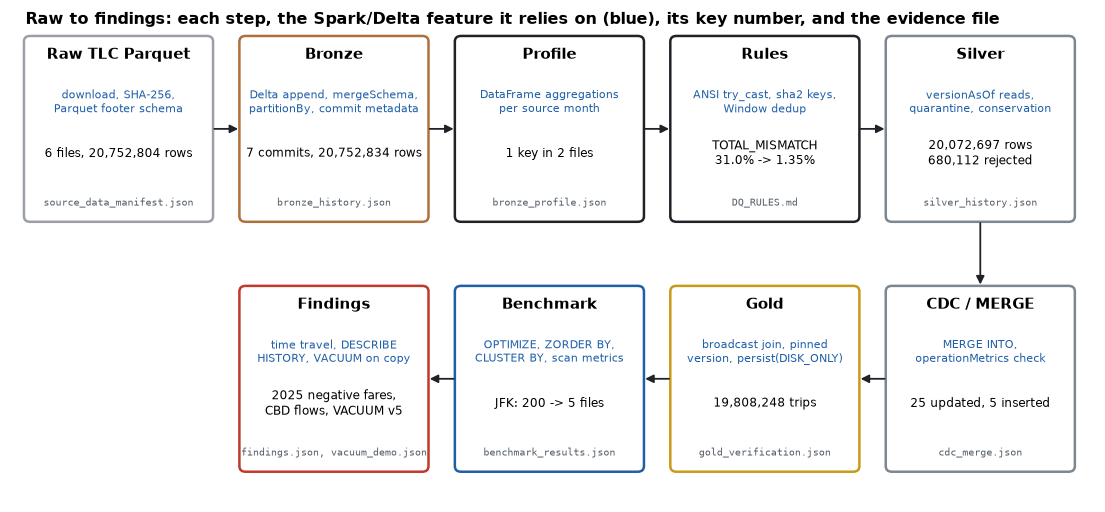

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b01_master_flow.png  |  source: all evidence files (see boxes)


In [5]:
@figure("b01_master_flow.png")
def _():
    need("manifest", "bronze_h", "silver_h", "profile", "cdc", "gold", "bench", "findings", "tt")
    B = batches(); raw = sum(f["rows"] for f in E["manifest"]["trip_files"].values())
    bronze = sum(metric(h, "numOutputRows") for h in E["bronze_h"])
    silver = E["tt"]["silver_rows_per_version"][-1]["rows"]
    rejected = sum(b["rejected"] for b in B)
    q1 = E["bench"]["summary"]["per_query"]["q1_zone"]
    dq = dq_rules_numbers()
    steps = [
        ("Raw TLC Parquet", "download, SHA-256,\nParquet footer schema", f"{len(E['manifest']['trip_files'])} files, {fmt(raw)} rows", "source_data_manifest.json", C["grey"]),
        ("Bronze", "Delta append, mergeSchema,\npartitionBy, commit metadata", f"{len(E['bronze_h'])} commits, {fmt(bronze)} rows", "bronze_history.json", C["bronze"]),
        ("Profile", "DataFrame aggregations\nper source month", f"{E['profile']['keys']['keys_seen_in_more_than_one_file']} key in 2 files", "bronze_profile.json", C["text"]),
        ("Rules", "ANSI try_cast, sha2 keys,\nWindow dedup", (f"TOTAL_MISMATCH\n{dq['before_pct']}% -> {dq['after_pct']}%" if dq else "contract TLC-v2"), "DQ_RULES.md", C["text"]),
        ("Silver", "versionAsOf reads,\nquarantine, conservation", f"{fmt(silver)} rows\n{fmt(rejected)} rejected", "silver_history.json", C["silver"]),
        ("CDC / MERGE", "MERGE INTO,\noperationMetrics check", f"{E['cdc']['merge_metrics']['updated']} updated, {E['cdc']['merge_metrics']['inserted']} inserted", "cdc_merge.json", C["silver"]),
        ("Gold", "broadcast join, pinned\nversion, persist(DISK_ONLY)", f"{fmt(E['gold']['gold_trips'])} trips", "gold_verification.json", C["gold"]),
        ("Benchmark", "OPTIMIZE, ZORDER BY,\nCLUSTER BY, scan metrics", f"JFK: {q1['baseline']['files_scanned']} -> {q1['zorder_1col']['files_scanned']} files", "benchmark_results.json", C["delta"]),
        ("Findings", "time travel, DESCRIBE\nHISTORY, VACUUM on copy", "2025 negative fares,\nCBD flows, VACUUM v5", "findings.json, vacuum_demo.json", C["accent"]),
    ]
    fig, ax = canvas(14, 6.4, (0, 14), (0, 7))
    pos = {}
    for i, (title, feat, num, ev, col) in enumerate(steps):
        row, k = (0, i) if i < 5 else (1, 9 - i)   # second row runs right-to-left under Silver
        x, y = 0.2 + k * 2.78, 4.0 - row * 3.55
        pos[i] = (x, y)
        ax.add_patch(FancyBboxPatch((x, y), 2.4, 2.6, boxstyle="round,pad=0.02,rounding_size=0.08", fc="white", ec=col, lw=1.8))
        ax.text(x + 1.2, y + 2.35, title, ha="center", va="center", weight="bold", fontsize=10.5)
        ax.text(x + 1.2, y + 1.68, feat, ha="center", va="center", fontsize=8, color=C["delta"])
        ax.text(x + 1.2, y + 0.95, num, ha="center", va="center", fontsize=8.8)
        ax.text(x + 1.2, y + 0.25, ev, ha="center", va="center", fontsize=7, color=C["muted"], family="monospace")
    for i in range(8):
        (x1, y1), (x2, y2) = pos[i], pos[i + 1]
        if i == 4:
            arrow(ax, (x1 + 1.2, y1), (x2 + 1.2, y2 + 2.6))
        elif i < 4:
            arrow(ax, (x1 + 2.4, y1 + 1.3), (x2, y2 + 1.3))
        else:
            arrow(ax, (x1, y1 + 1.3), (x2 + 2.4, y2 + 1.3))
    ax.text(0.2, 6.85, "Raw to findings: each step, the Spark/Delta feature it relies on (blue), its key number, and the evidence file",
            fontsize=11.5, weight="bold", va="center")
    save(fig, "b01_master_flow.png", "all evidence files (see boxes)")

### b02 — row conservation for all six months (extends `silver_funnel_2025_03.png`)

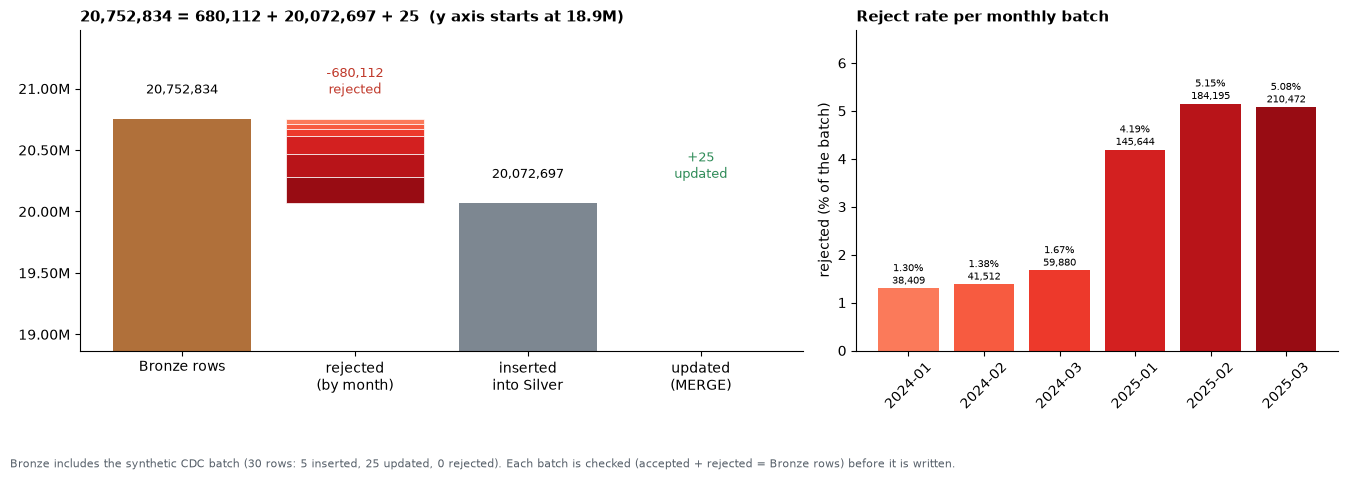

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b02_row_conservation_waterfall.png  |  source: bronze_history.json, silver_history.json


In [6]:
@figure("b02_row_conservation_waterfall.png")
def _():
    B = batches()
    real = [b for b in B if not b["synthetic"]]
    cdc = [b for b in B if b["synthetic"]]
    bronze_total = sum(b["bronze"] for b in B)
    rejected = [b["rejected"] for b in real]
    inserted = sum(b["inserted"] for b in B); updated = sum(b["updated"] for b in B)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.8), gridspec_kw={"width_ratios": [1.5, 1]})
    a1.bar(0, bronze_total, color=C["bronze"]); a1.text(0, bronze_total * 1.01, fmt(bronze_total), ha="center", fontsize=9)
    top = bronze_total
    cmap = plt.get_cmap("Reds")(np.linspace(0.45, 0.9, len(real)))
    for b, col in zip(real, cmap):
        a1.bar(1, b["rejected"], bottom=top - b["rejected"], color=col, edgecolor="white", lw=0.5)
        top -= b["rejected"]
    a1.text(1, bronze_total * 1.01, f"-{fmt(sum(rejected))}\nrejected", ha="center", fontsize=9, color=C["accent"])
    a1.bar(2, inserted, color=C["silver"]); a1.text(2, inserted * 1.01, fmt(inserted), ha="center", fontsize=9)
    a1.bar(3, updated, bottom=inserted, color=C["ok"]); a1.text(3, inserted * 1.01, f"+{fmt(updated)}\nupdated", ha="center", fontsize=9, color=C["ok"])
    lo = min(inserted, bronze_total) * 0.94
    a1.set_ylim(lo, bronze_total * 1.035)
    a1.set_xticks(range(4), ["Bronze rows", "rejected\n(by month)", "inserted\ninto Silver", "updated\n(MERGE)"])
    a1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
    a1.set_title(f"{fmt(bronze_total)} = {fmt(sum(rejected))} + {fmt(inserted)} + {fmt(updated)}  (y axis starts at {lo/1e6:.1f}M)", fontsize=11)
    months = [b["month"] for b in real]; rate = [100 * b["rejected"] / b["bronze"] for b in real]
    a2.bar(months, rate, color=cmap)
    for i, (r, b) in enumerate(zip(rate, real)):
        a2.text(i, r + 0.1, f"{r:.2f}%\n{fmt(b['rejected'])}", ha="center", fontsize=7.5)
    a2.set_ylabel("rejected (% of the batch)"); a2.set_ylim(0, max(rate) * 1.3); a2.tick_params(axis="x", rotation=45)
    a2.set_title("Reject rate per monthly batch", fontsize=11)
    note = (f"Bronze includes the synthetic CDC batch ({fmt(cdc[0]['bronze'])} rows: {cdc[0]['inserted']} inserted, {cdc[0]['updated']} updated, 0 rejected). "
            if cdc else "") + "Each batch is checked (accepted + rejected = Bronze rows) before it is written."
    footnote(fig, note, 0.1)
    save(fig, "b02_row_conservation_waterfall.png", "bronze_history.json, silver_history.json")

### b03 — question → evidence map (for the live demo)

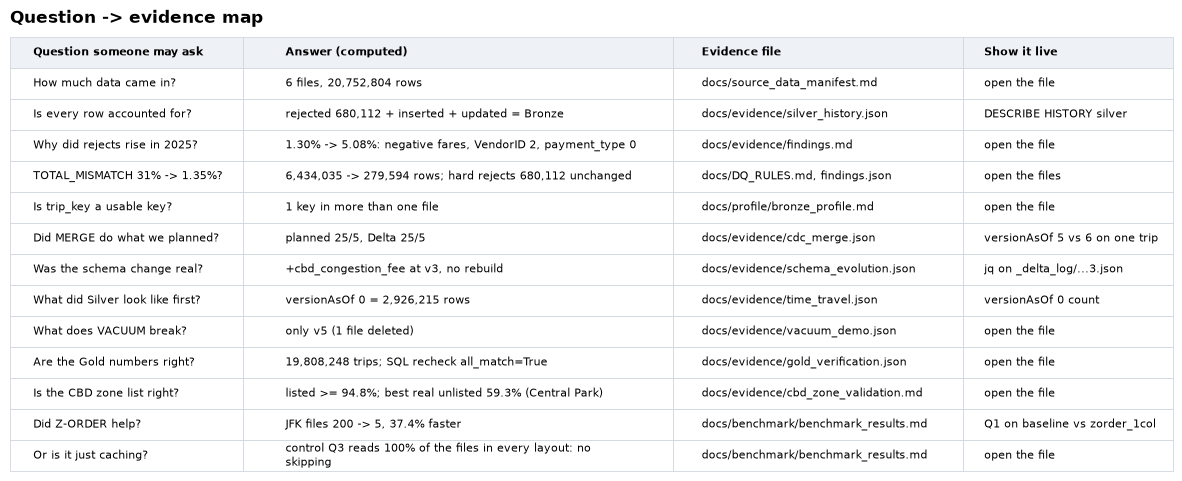

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b03_question_evidence_map.png  |  source: evidence files listed in the table


In [7]:
@figure("b03_question_evidence_map.png")
def _():
    need("manifest", "findings", "profile", "cdc", "schema", "tt", "vacuum", "gold", "cbd_zones", "bench")
    B = [b for b in batches() if not b["synthetic"]]
    raw = sum(f["rows"] for f in E["manifest"]["trip_files"].values())
    dq = dq_rules_numbers(); q = E["bench"]["summary"]["per_query"]
    z = pd.DataFrame(E["cbd_zones"]); z = z[z.verdict != "TOO_FEW_TRIPS"]
    real_unlisted = z[(~z.is_cbd) & ~z.PULocationID.isin([264, 265]) & ~z.borough.isin(["Unknown", "N/A"])]
    lo, hi = z[z.is_cbd].sort_values("fee_share").iloc[0], real_unlisted.sort_values("fee_share").iloc[-1]
    ev = E["schema"]
    rows = [
        ("How much data came in?", f"{len(E['manifest']['trip_files'])} files, {fmt(raw)} rows", "docs/source_data_manifest.md", "open the file"),
        ("Is every row accounted for?", f"rejected {fmt(sum(b['rejected'] for b in B))} + inserted + updated = Bronze", "docs/evidence/silver_history.json", "DESCRIBE HISTORY silver"),
        ("Why did rejects rise in 2025?", f"{100*B[0]['rejected']/B[0]['bronze']:.2f}% -> {100*B[-1]['rejected']/B[-1]['bronze']:.2f}%: negative fares, VendorID 2, payment_type 0", "docs/evidence/findings.md", "open the file"),
        ("TOTAL_MISMATCH 31% -> 1.35%?", f"{fmt(dq['before'])} -> {fmt(dq['after'])} rows; hard rejects {fmt(dq['hard'])} unchanged" if dq else "see DQ_RULES.md", "docs/DQ_RULES.md, findings.json", "open the files"),
        ("Is trip_key a usable key?", f"{E['profile']['keys']['keys_seen_in_more_than_one_file']} key in more than one file", "docs/profile/bronze_profile.md", "open the file"),
        ("Did MERGE do what we planned?", f"planned {E['cdc']['planned']['updates']}/{E['cdc']['planned']['inserts']}, Delta {E['cdc']['merge_metrics']['updated']}/{E['cdc']['merge_metrics']['inserted']}", "docs/evidence/cdc_merge.json", "versionAsOf 5 vs 6 on one trip"),
        ("Was the schema change real?", f"+{', '.join(ev['bronze']['evolution_event']['added'])} at v{ev['bronze']['evolution_event']['version']}, no rebuild", "docs/evidence/schema_evolution.json", "jq on _delta_log/...3.json"),
        ("What did Silver look like first?", f"versionAsOf 0 = {fmt(E['tt']['silver_rows_per_version'][0]['rows'])} rows", "docs/evidence/time_travel.json", "versionAsOf 0 count"),
        ("What does VACUUM break?", f"only v{', v'.join(map(str, E['vacuum']['broken_versions']))} ({E['vacuum']['files_listed_by_dry_run']} file deleted)", "docs/evidence/vacuum_demo.json", "open the file"),
        ("Are the Gold numbers right?", f"{fmt(E['gold']['gold_trips'])} trips; SQL recheck all_match={E['gold']['verification']['all_match']}", "docs/evidence/gold_verification.json", "open the file"),
        ("Is the CBD zone list right?", f"listed >= {100*lo.fee_share:.1f}%; best real unlisted {100*hi.fee_share:.1f}% ({hi.zone})", "docs/evidence/cbd_zone_validation.md", "open the file"),
        ("Did Z-ORDER help?", f"JFK files {q['q1_zone']['baseline']['files_scanned']} -> {q['q1_zone']['zorder_1col']['files_scanned']}, {q['q1_zone']['zorder_1col']['improvement_pct']:.1f}% faster", "docs/benchmark/benchmark_results.md", "Q1 on baseline vs zorder_1col"),
        ("Or is it just caching?", f"control Q3 reads {min(100 * v['files_scanned'] / E['bench']['variants'][k]['files'] for k, v in q['q3_control'].items()):.0f}% of the files in every layout: no skipping", "docs/benchmark/benchmark_results.md", "open the file"),
    ]
    df = pd.DataFrame(rows, columns=["Question someone may ask", "Answer (computed)", "Evidence file", "Show it live"])
    fig = table_figure(df, "Question -> evidence map", width=15, col_widths=[0.2, 0.37, 0.25, 0.18], fontsize=8.2, row_h=0.36)
    save(fig, "b03_question_evidence_map.png", "evidence files listed in the table")

## B. Spark-specific value
### b04 — Spark/Delta feature → where in the code → evidence (located by searching the source)

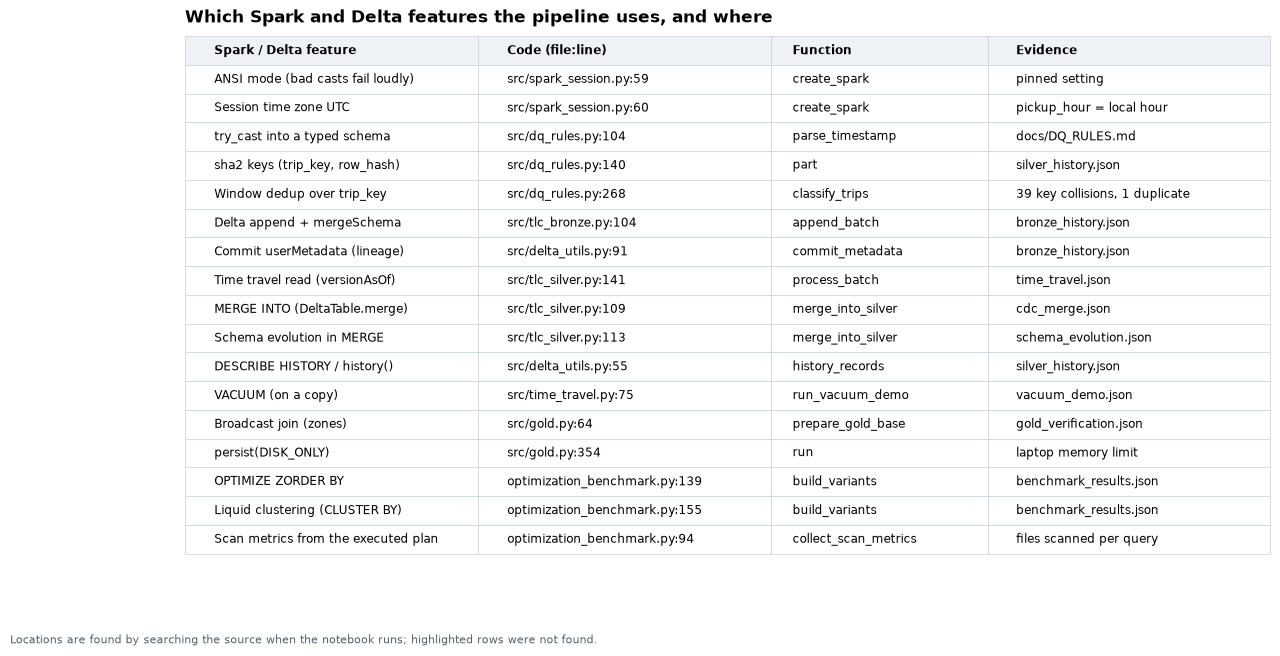

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b04_spark_feature_table.png  |  source: source code search


In [8]:
FEATURES = [
    ("ANSI mode (bad casts fail loudly)", r'\.config\("spark\.sql\.ansi\.enabled"', "src/spark_session.py", "pinned setting"),
    ("Session time zone UTC", r'\.config\("spark\.sql\.session\.timeZone"', "src/spark_session.py", "pickup_hour = local hour"),
    ("try_cast into a typed schema", r'try_cast\(', "src/dq_rules.py", "docs/DQ_RULES.md"),
    ("sha2 keys (trip_key, row_hash)", r'F\.sha2\(', "src/dq_rules.py", "silver_history.json"),
    ("Window dedup over trip_key", r'Window\.partitionBy\(', "src/dq_rules.py", "39 key collisions, 1 duplicate"),
    ("Delta append + mergeSchema", r'option\("mergeSchema"', "src/tlc_bronze.py", "bronze_history.json"),
    ("Commit userMetadata (lineage)", r'commitInfo\.userMetadata', "src/delta_utils.py", "bronze_history.json"),
    ("Time travel read (versionAsOf)", r'versionAsOf', "src/tlc_silver.py", "time_travel.json"),
    ("MERGE INTO (DeltaTable.merge)", r'\.merge\(', "src/tlc_silver.py", "cdc_merge.json"),
    ("Schema evolution in MERGE", r'withSchemaEvolution', "src/tlc_silver.py", "schema_evolution.json"),
    ("DESCRIBE HISTORY / history()", r'table\.history\(', "src/delta_utils.py", "silver_history.json"),
    ("VACUUM (on a copy)", r'VACUUM delta\.', "src/time_travel.py", "vacuum_demo.json"),
    ("Broadcast join (zones)", r'F\.broadcast\(', "src/gold.py", "gold_verification.json"),
    ("persist(DISK_ONLY)", r'DISK_ONLY', "src/gold.py", "laptop memory limit"),
    ("OPTIMIZE ZORDER BY", r'executeZOrderBy', "optimization_benchmark.py", "benchmark_results.json"),
    ("Liquid clustering (CLUSTER BY)", r'clusterBy', "optimization_benchmark.py", "benchmark_results.json"),
    ("Scan metrics from the executed plan", r'numFiles', "optimization_benchmark.py", "files scanned per query"),
]

def locate(pattern, rel):
    lines = (REPO / rel).read_text().splitlines()
    for i, line in enumerate(lines):
        if re.search(pattern, line) and not line.lstrip().startswith("#"):
            fn = next((re.match(r"\s*def (\w+)", l)[1] for l in reversed(lines[:i + 1]) if re.match(r"\s*def (\w+)", l)), "module level")
            return f"{rel}:{i + 1}", fn
    return f"{rel}: not found", "-"

@figure("b04_spark_feature_table.png")
def _():
    rows = []
    for feat, pat, rel, ev in FEATURES:
        where, fn = locate(pat, rel)
        rows.append((feat, where, fn, ev))
    df = pd.DataFrame(rows, columns=["Spark / Delta feature", "Code (file:line)", "Function", "Evidence"])
    missing = [i for i, r in enumerate(rows) if "not found" in r[1]]
    fig = table_figure(df, "Which Spark and Delta features the pipeline uses, and where", width=14,
                       col_widths=[0.27, 0.27, 0.2, 0.26], highlight_rows=missing,
                       note="Locations are found by searching the source when the notebook runs; highlighted rows were not found.")
    save(fig, "b04_spark_feature_table.png", "source code search")

### b05 — physical plans: `PushedFilters` (Z-ORDER query), `BroadcastHashJoin` (Gold zone join), `Exchange hashpartitioning` (dedup)
Each query runs once on one month (`MONTH`) or on the benchmark table; the plan shown is the executed (final adaptive) plan.

26/10/02 03:18:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


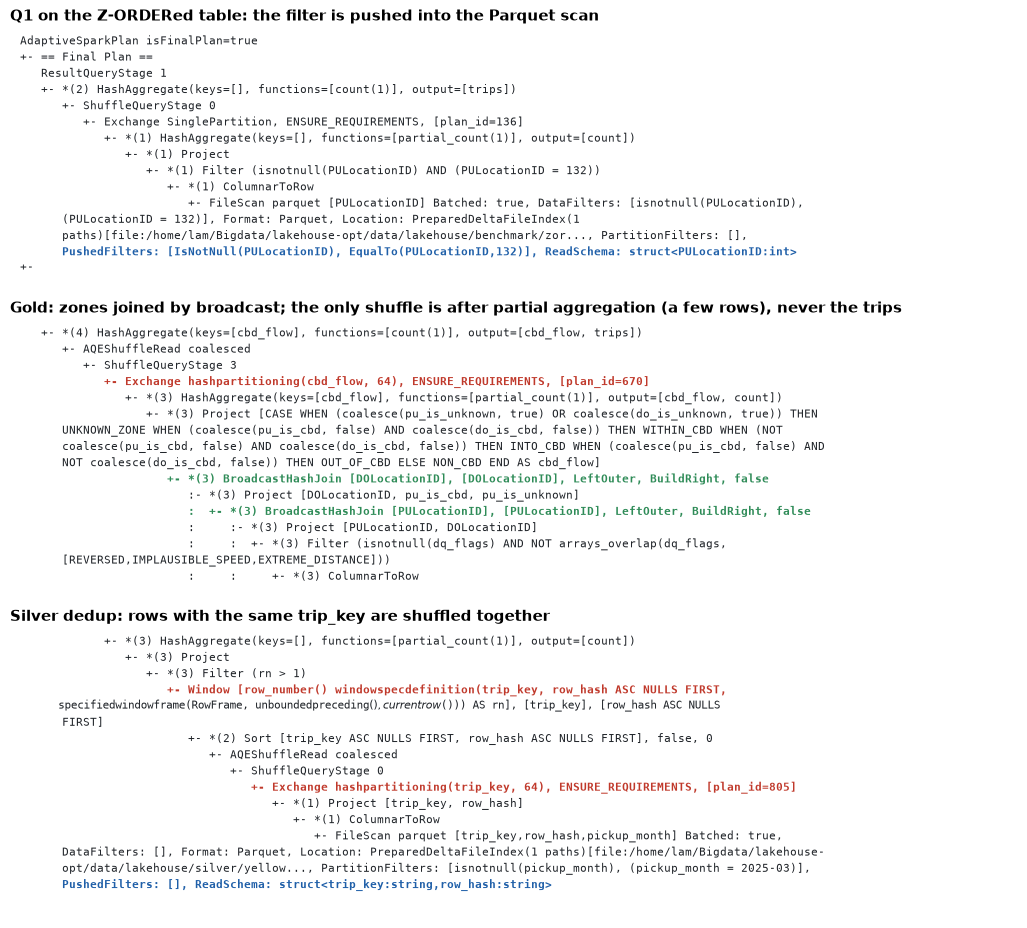

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b05_physical_plans.png  |  source: executed plans on 2025-03 and benchmark/zorder_1col


In [9]:
from pyspark.sql import functions as F, Window

def month_silver():
    return load(P.silver_trips).filter(F.col("pickup_month") == MONTH)

def q_zorder():
    df = load(P.benchmark_dir / "zorder_1col").filter(F.col("PULocationID") == 132).agg(F.count(F.lit(1)).alias("trips"))
    df.collect(); return df

def q_gold_join():
    from src.gold import prepare_gold_base
    base = prepare_gold_base(month_silver(), load(P.silver_dim_zone), [MONTH])
    df = base.groupBy("cbd_flow").agg(F.count(F.lit(1)).alias("trips"))
    df.collect(); return df

def dedup_df():
    w = Window.partitionBy("trip_key").orderBy("row_hash")
    return month_silver().select("trip_key", "row_hash").withColumn("rn", F.row_number().over(w)).filter("rn > 1").agg(F.count(F.lit(1)).alias("extra_copies"))

def q_dedup():
    df = dedup_df(); df.collect(); return df

KEYS = {"PushedFilters": C["delta"], "BroadcastHashJoin": C["ok"], "BroadcastExchange": C["ok"],
        "Exchange hashpartitioning": C["accent"], "Window": C["accent"]}

def plan_lines(text, keep=16, width=118):
    lines = [l for l in text.splitlines() if l.strip() and "Initial Plan" not in l]
    if "== Initial Plan ==" in text:
        lines = text.split("== Initial Plan ==")[0].splitlines()
    out = []
    for l in lines:
        l = re.sub(r"#\d+L?", "", l)
        out.extend(textwrap.wrap(l, width, subsequent_indent="      ") or [""])
    hits = [i for i, l in enumerate(out) if any(k in l for k in KEYS)]
    if len(out) > keep and hits:
        start = max(0, min(hits) - 3); out = out[start:start + keep]
    return out[:keep]

@figure("b05_physical_plans.png")
def _():
    need_spark(P.silver_trips, P.silver_dim_zone, P.benchmark_dir / "zorder_1col")
    panels = [("Q1 on the Z-ORDERed table: the filter is pushed into the Parquet scan", q_zorder),
              ("Gold: zones joined by broadcast; the only shuffle is after partial aggregation (a few rows), never the trips", q_gold_join),
              ("Silver dedup: rows with the same trip_key are shuffled together", q_dedup)]
    blocks = [(title, plan_lines(plan_string(fn()))) for title, fn in panels]
    n = sum(len(b) + 3 for _, b in blocks)
    fig, ax = plt.subplots(figsize=(13, 0.2 * n + 0.6)); ax.axis("off")
    y = 1.0; step = 1.0 / n
    for title, lines in blocks:
        ax.text(0, y, title, weight="bold", fontsize=10.5, va="top", transform=ax.transAxes); y -= 1.6 * step
        for l in lines:
            col = next((v for k, v in KEYS.items() if k in l), C["text"])
            ax.text(0.01, y, l, family="monospace", fontsize=7.6, color=col, weight="bold" if col != C["text"] else "normal",
                    va="top", transform=ax.transAxes)
            y -= step
        y -= 1.4 * step
    save(fig, "b05_physical_plans.png", f"executed plans on {MONTH} and benchmark/zorder_1col")

### b06 — Spark UI stage view of the dedup (shuffle-heavy), read from the Spark UI REST API

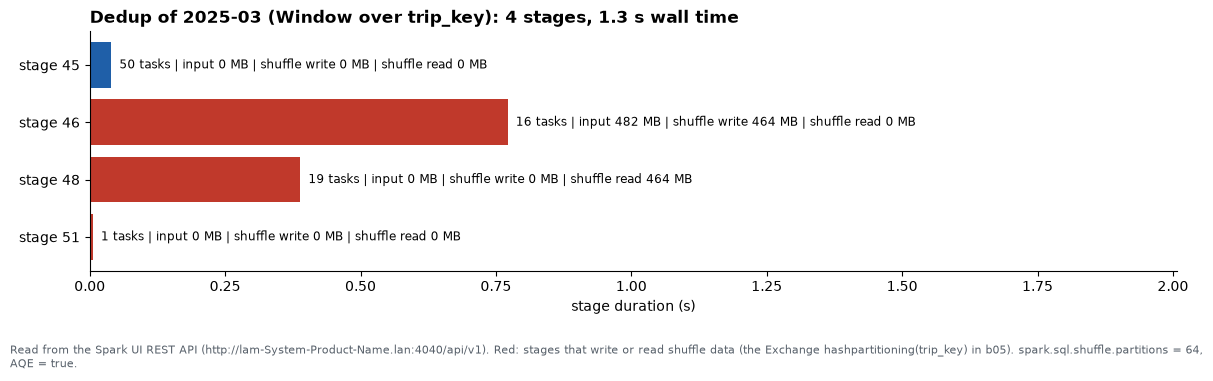

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b06_spark_stage_view_dedup.png  |  source: Spark UI REST API (stages of one dedup job)


In [10]:
def ui_get(path):
    base = spark.sparkContext.uiWebUrl
    with urllib.request.urlopen(f"{base}/api/v1/applications/{spark.sparkContext.applicationId}/{path}", timeout=10) as r:
        return json.loads(r.read().decode())

def ui_time(s):
    return datetime.strptime(s.replace("GMT", ""), "%Y-%m-%dT%H:%M:%S.%f") if s else None

@figure("b06_spark_stage_view_dedup.png")
def _():
    need_spark(P.silver_trips)
    if not spark.sparkContext.uiWebUrl:
        raise SkipFigure("Spark UI is disabled")
    group = f"backup_dedup_{int(time.time())}"
    spark.sparkContext.setJobGroup(group, "dedup over trip_key for the stage view")
    t0 = time.perf_counter(); dedup_df().collect(); wall = time.perf_counter() - t0
    spark.sparkContext.setJobGroup("", "")
    jobs = [j for j in ui_get("jobs") if j.get("jobGroup") == group]
    stage_ids = sorted({s for j in jobs for s in j["stageIds"]})
    rows = []
    for sid in stage_ids:
        att = ui_get(f"stages/{sid}")[0]
        if att.get("status") != "COMPLETE":
            continue
        dur = (ui_time(att.get("completionTime")) - ui_time(att.get("submissionTime"))).total_seconds() if att.get("completionTime") else 0
        rows.append(dict(stage=sid, name=att["name"].split(" at ")[0], tasks=att["numTasks"], dur=dur,
                         input_mb=att.get("inputBytes", 0) / 2**20, sw_mb=att.get("shuffleWriteBytes", 0) / 2**20,
                         sr_mb=att.get("shuffleReadBytes", 0) / 2**20))
    if not rows:
        raise SkipFigure("no completed stages found for the job group")
    df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(12, 0.55 * len(df) + 1.6))
    cols = [C["accent"] if r.sw_mb > 0 or r.sr_mb > 0 else C["delta"] for r in df.itertuples()]
    ax.barh([f"stage {r.stage}" for r in df.itertuples()], df.dur, color=cols)
    for i, r in enumerate(df.itertuples()):
        ax.text(r.dur, i, f"  {r.tasks} tasks | input {r.input_mb:,.0f} MB | shuffle write {r.sw_mb:,.0f} MB | shuffle read {r.sr_mb:,.0f} MB",
                va="center", fontsize=8.5)
    ax.invert_yaxis(); ax.set_xlabel("stage duration (s)"); ax.set_xlim(0, df.dur.max() * 2.6)
    ax.set_title(f"Dedup of {MONTH} (Window over trip_key): {len(df)} stages, {wall:.1f} s wall time")
    footnote(fig, f"Read from the Spark UI REST API ({spark.sparkContext.uiWebUrl}/api/v1). Red: stages that write or read shuffle data "
                  f"(the Exchange hashpartitioning(trip_key) in b05). spark.sql.shuffle.partitions = {spark.conf.get('spark.sql.shuffle.partitions')}, AQE = {spark.conf.get('spark.sql.adaptive.enabled')}.", 0.12)
    save(fig, "b06_spark_stage_view_dedup.png", "Spark UI REST API (stages of one dedup job)")

### b07 — broadcast vs sort-merge join (one small run: plan + time)

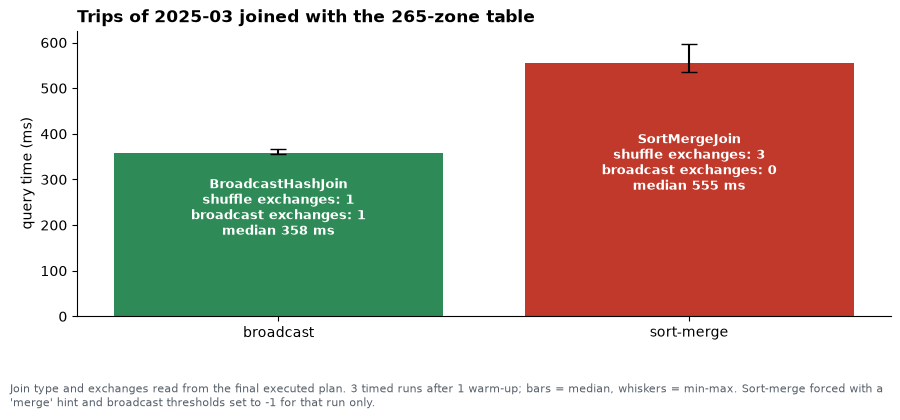

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b07_broadcast_vs_sortmerge.png  |  source: live runs on Silver + dim_zone


In [11]:
def join_query(strategy):
    trips = month_silver().select("PULocationID", "fare_amount")
    zones = load(P.silver_dim_zone).select(F.col("LocationID").alias("PULocationID"), "borough")
    zones = F.broadcast(zones) if strategy == "broadcast" else zones.hint("merge")
    return trips.join(zones, "PULocationID").groupBy("borough").agg(F.sum("fare_amount").alias("fares"))

def join_kind(plan):
    for k in ("BroadcastHashJoin", "SortMergeJoin", "ShuffledHashJoin", "BroadcastNestedLoopJoin"):
        if k in plan:
            return k
    return "?"

@figure("b07_broadcast_vs_sortmerge.png")
def _():
    need_spark(P.silver_trips, P.silver_dim_zone)
    keys = ["spark.sql.autoBroadcastJoinThreshold", "spark.sql.adaptive.autoBroadcastJoinThreshold"]
    saved = {k: spark.conf.get(k, None) for k in keys}
    res = {}
    try:
        for strategy in ("broadcast", "sort-merge"):
            if strategy == "sort-merge":
                for k in keys:
                    spark.conf.set(k, "-1")
            ms = timed(lambda: join_query(strategy).collect())
            df = join_query(strategy); df.collect(); plan = plan_string(df)
            final = plan.split("== Initial Plan ==")[0]
            res[strategy] = dict(ms=ms, join=join_kind(final), shuffles=final.count("Exchange hashpartitioning"),
                                 broadcasts=final.count("BroadcastExchange"))
    finally:
        for k, v in saved.items():
            spark.conf.unset(k) if v is None else spark.conf.set(k, v)
    fig, ax = plt.subplots(figsize=(9, 4.2))
    names = list(res)
    med = [statistics.median(res[n]["ms"]) for n in names]
    err = [[m - min(res[n]["ms"]) for n, m in zip(names, med)], [max(res[n]["ms"]) - m for n, m in zip(names, med)]]
    ax.bar(names, med, yerr=err, capsize=6, color=[C["ok"], C["accent"]])
    for i, n in enumerate(names):
        ax.text(i, med[i] * 0.5, f"{res[n]['join']}\nshuffle exchanges: {res[n]['shuffles']}\nbroadcast exchanges: {res[n]['broadcasts']}\nmedian {med[i]:.0f} ms",
                ha="center", color="white", fontsize=9, weight="bold")
    ax.set_ylabel("query time (ms)")
    ax.set_title(f"Trips of {MONTH} joined with the 265-zone table")
    footnote(fig, f"Join type and exchanges read from the final executed plan. {REPEATS} timed runs after 1 warm-up; bars = median, whiskers = min-max. "
                  "Sort-merge forced with a 'merge' hint and broadcast thresholds set to -1 for that run only.", 0.14)
    save(fig, "b07_broadcast_vs_sortmerge.png", "live runs on Silver + dim_zone")

### b08 — shuffle-partitions sweep on the dedup (a flat result is a valid finding on one machine)

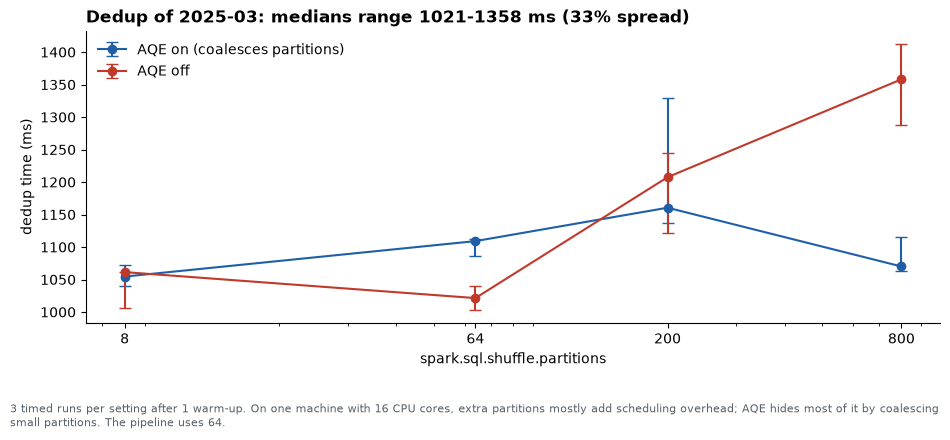

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b08_shuffle_partitions_sweep.png  |  source: live runs on Silver


In [12]:
@figure("b08_shuffle_partitions_sweep.png")
def _():
    need_spark(P.silver_trips)
    keys = ["spark.sql.shuffle.partitions", "spark.sql.adaptive.enabled"]
    saved = {k: spark.conf.get(k) for k in keys}
    rows = []
    try:
        for aqe in ("true", "false"):
            spark.conf.set("spark.sql.adaptive.enabled", aqe)
            for n in SWEEP_PARTITIONS:
                spark.conf.set("spark.sql.shuffle.partitions", str(n))
                ms = timed(lambda: dedup_df().collect())
                rows.append(dict(aqe=aqe, partitions=n, median=statistics.median(ms), lo=min(ms), hi=max(ms)))
    finally:
        for k, v in saved.items():
            spark.conf.set(k, v)
    df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(9.5, 4.4))
    for aqe, col in (("true", C["delta"]), ("false", C["accent"])):
        d = df[df.aqe == aqe]
        ax.errorbar(d.partitions, d["median"], yerr=[d["median"] - d.lo, d.hi - d["median"]], marker="o", capsize=4, color=col,
                    label=f"AQE {'on (coalesces partitions)' if aqe == 'true' else 'off'}")
    ax.set_xscale("log"); ax.set_xticks(SWEEP_PARTITIONS, [str(n) for n in SWEEP_PARTITIONS])
    ax.set_xlabel("spark.sql.shuffle.partitions"); ax.set_ylabel("dedup time (ms)"); ax.legend(frameon=False)
    spread = 100 * (df["median"].max() - df["median"].min()) / df["median"].min()
    ax.set_title(f"Dedup of {MONTH}: medians range {df['median'].min():.0f}-{df['median'].max():.0f} ms ({spread:.0f}% spread)")
    footnote(fig, f"{REPEATS} timed runs per setting after 1 warm-up. On one machine with {CORES}, extra partitions mostly add "
                  "scheduling overhead; AQE hides most of it by coalescing small partitions. The pipeline uses 64.", 0.12)
    save(fig, "b08_shuffle_partitions_sweep.png", "live runs on Silver")

### b09 — the cost of MERGE (copy-on-write) and why deletion vectors exist
From the existing history of the CDC MERGE. Set `RUN_DV_EXPERIMENT = True` to also measure the same kind of MERGE with deletion vectors on a scratch copy.

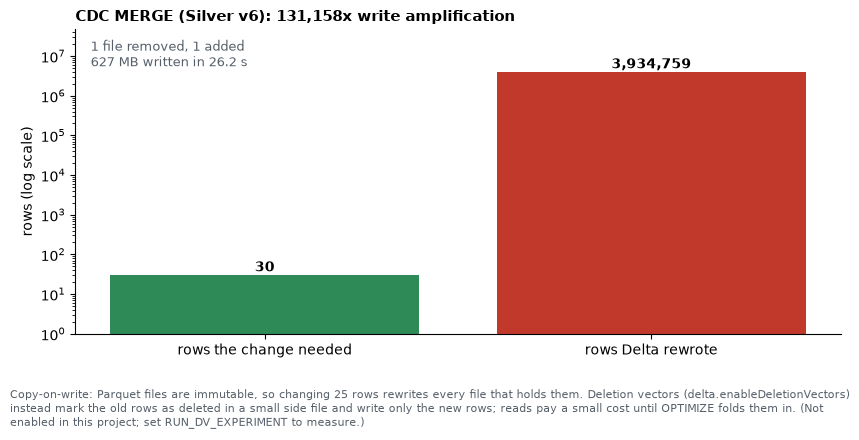

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b09_merge_cost_deletion_vectors.png  |  source: silver_history.json


In [13]:
def dv_experiment():
    from delta.tables import DeltaTable
    src = month_silver()
    feed = (src.orderBy("trip_key").limit(25)
               .select("pickup_month", "trip_key", (F.col("tip_amount") + 2).alias("tip_amount"))).cache()
    feed.count()
    base = Path(P.scratch_dir) / "dv_experiment"
    out = {}
    try:
        for dv in (False, True):
            path = str(base / ("dv_on" if dv else "dv_off"))
            shutil.rmtree(path, ignore_errors=True)
            src.coalesce(1).write.format("delta").save(path)
            spark.sql(f"ALTER TABLE delta.`{path}` SET TBLPROPERTIES ('delta.enableDeletionVectors' = '{str(dv).lower()}')")
            t0 = time.perf_counter()
            (DeltaTable.forPath(spark, path).alias("t")
               .merge(feed.alias("s"), "t.pickup_month = s.pickup_month AND t.trip_key = s.trip_key")
               .whenMatchedUpdate(set={"tip_amount": "s.tip_amount"}).execute())
            ms = (time.perf_counter() - t0) * 1000
            m = DeltaTable.forPath(spark, path).history(1).collect()[0]["operationMetrics"]
            out["with deletion vectors" if dv else "copy-on-write"] = dict(
                ms=ms, copied=int(m.get("numTargetRowsCopied", 0)), updated=int(m.get("numTargetRowsUpdated", 0)),
                dvs=int(m.get("numTargetDeletionVectorsAdded", 0)), mb_added=int(m.get("numTargetBytesAdded", 0)) / 2**20)
    finally:
        feed.unpersist(); shutil.rmtree(base, ignore_errors=True)
    return out

@figure("b09_merge_cost_deletion_vectors.png")
def _():
    need("silver_h")
    h = next(x for x in E["silver_h"] if not meta(x).get("batch_id", "yellow_").startswith("yellow_"))
    changed, rewritten = metric(h, "numSourceRows"), metric(h, "numOutputRows")
    exp = None
    if RUN_DV_EXPERIMENT:
        need_spark(P.silver_trips)
        if TABLE_FORMAT != "delta":
            raise SkipFigure("the deletion-vector experiment needs Delta")
        exp = dv_experiment()
    fig, axes = plt.subplots(1, 2 if exp else 1, figsize=(13 if exp else 8.5, 4.4))
    a1 = axes[0] if exp else axes
    a1.bar(["rows the change needed", "rows Delta rewrote"], [changed, rewritten], color=[C["ok"], C["accent"]])
    a1.set_yscale("log"); a1.set_ylabel("rows (log scale)")
    for i, v in enumerate([changed, rewritten]):
        a1.text(i, v * 1.25, fmt(v), ha="center", fontsize=10, weight="bold")
    a1.set_title(f"CDC MERGE (Silver v{h['version']}): {fmt(rewritten // max(changed, 1))}x write amplification", fontsize=11)
    a1.text(0.02, 0.97, f"{metric(h, 'numTargetFilesRemoved')} file removed, {metric(h, 'numTargetFilesAdded')} added\n"
                       f"{metric(h, 'numTargetBytesAdded') / 1e6:,.0f} MB written in {metric(h, 'executionTimeMs') / 1000:.1f} s",
            transform=a1.transAxes, ha="left", va="top", fontsize=9, color=C["muted"])
    a1.set_ylim(1, rewritten * 12)
    if exp:
        names = list(exp)
        x = np.arange(len(names))
        axes[1].bar(x - 0.2, [exp[n]["copied"] + 1 for n in names], 0.4, color=C["accent"], label="rows copied (+1 for log scale)")
        axes[1].set_yscale("log"); axes[1].set_xticks(x, names)
        ax2 = axes[1].twinx(); ax2.bar(x + 0.2, [exp[n]["ms"] for n in names], 0.4, color=C["delta"], label="time (ms)")
        for i, n in enumerate(names):
            axes[1].text(i - 0.2, exp[n]["copied"] + 1, f"{fmt(exp[n]['copied'])}\nDVs: {exp[n]['dvs']}", ha="center", va="bottom", fontsize=8)
            ax2.text(i + 0.2, exp[n]["ms"], f"{exp[n]['ms']:.0f} ms", ha="center", va="bottom", fontsize=8)
        axes[1].set_title(f"Measured on a scratch copy of {MONTH}: 25-row tip correction", fontsize=11)
    footnote(fig, "Copy-on-write: Parquet files are immutable, so changing 25 rows rewrites every file that holds them. "
                  "Deletion vectors (delta.enableDeletionVectors) instead mark the old rows as deleted in a small side file and write only "
                  "the new rows; reads pay a small cost until OPTIMIZE folds them in." + ("" if exp else " (Not enabled in this project; set RUN_DV_EXPERIMENT to measure.)"), 0.14)
    save(fig, "b09_merge_cost_deletion_vectors.png", "silver_history.json" + (" + scratch-copy experiment" if exp else ""))

## C. Parameter tracking
### b10 — run configuration (live Spark conf when available, otherwise the pinned values in the source)

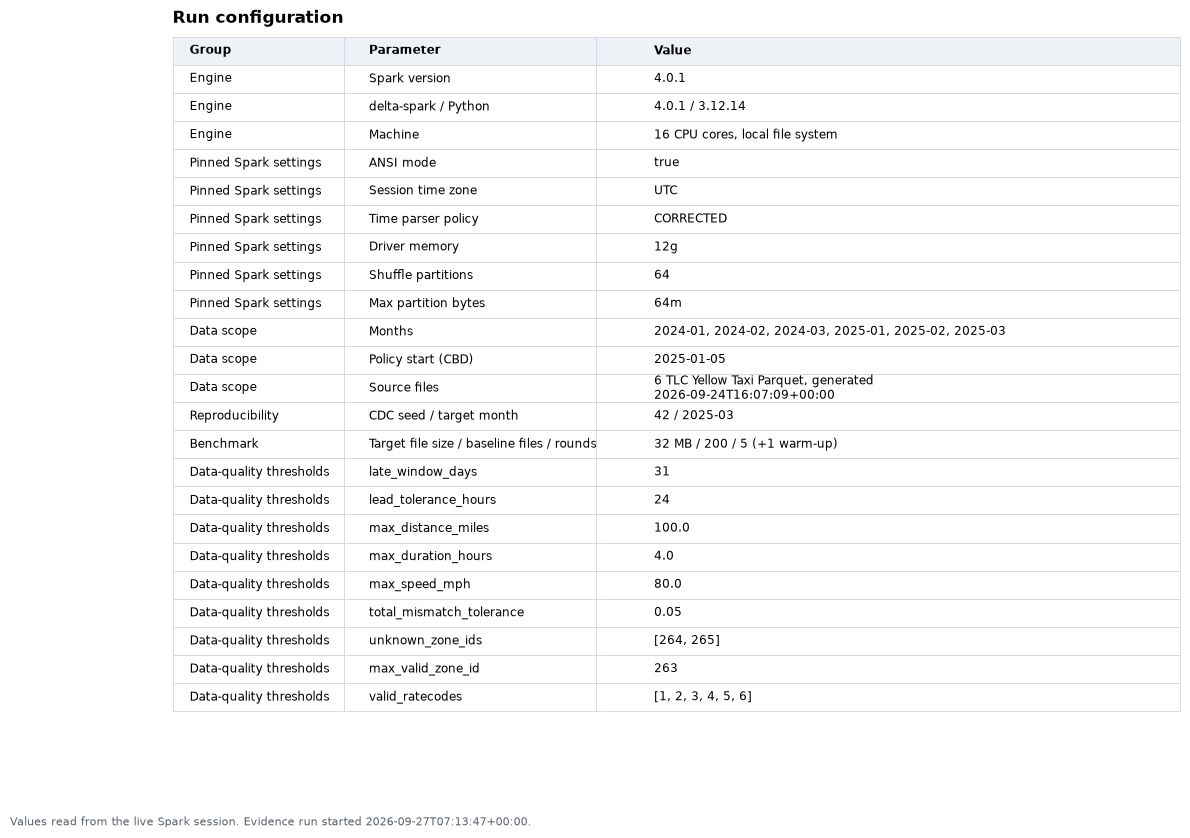

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b10_run_configuration.png  |  source: pipeline_run.json, benchmark_results.json, cdc_merge.json, bronze_profile.json, spark conf


In [14]:
@figure("b10_run_configuration.png")
def _():
    need("run", "bench", "cdc", "profile", "manifest")
    src_conf = dict(re.findall(r'\.config\("([\w.]+)",\s*([^)]+?)\)\s*$', (REPO / "src/spark_session.py").read_text(), re.M))
    def conf(key):
        if spark is not None:
            try:
                return spark.conf.get(key)
            except Exception:
                pass
        return src_conf.get(key, "-").strip('"') + " (source)"
    try:
        from importlib.metadata import version
        delta_v = version("delta-spark")
    except Exception:
        delta_v = "-"
    b = E["bench"]
    rows = [
        ("Engine", "Spark version", spark.version if spark else E["run"].get("spark", "-")),
        ("Engine", "delta-spark / Python", f"{delta_v} / {platform.python_version()}"),
        ("Engine", "Machine", f"{CORES}, local file system"),
        ("Pinned Spark settings", "ANSI mode", conf("spark.sql.ansi.enabled")),
        ("Pinned Spark settings", "Session time zone", conf("spark.sql.session.timeZone")),
        ("Pinned Spark settings", "Time parser policy", conf("spark.sql.legacy.timeParserPolicy")),
        ("Pinned Spark settings", "Driver memory", conf("spark.driver.memory")),
        ("Pinned Spark settings", "Shuffle partitions", conf("spark.sql.shuffle.partitions")),
        ("Pinned Spark settings", "Max partition bytes", conf("spark.sql.files.maxPartitionBytes")),
        ("Data scope", "Months", ", ".join(E["run"].get("months", []))),
        ("Data scope", "Policy start (CBD)", str(source_constant("src/config.py", "CBD_POLICY_START"))),
        ("Data scope", "Source files", f"{len(E['manifest']['trip_files'])} TLC Yellow Taxi Parquet, generated {E['manifest'].get('generated_at', '-')}"),
        ("Reproducibility", "CDC seed / target month", f"{E['cdc']['seed']} / {E['cdc']['target_month']}"),
        ("Benchmark", "Target file size / baseline files / rounds", f"{b['target_file_mb']} MB / {b['baseline_files']} / {b['rounds']} (+1 warm-up)"),
    ] + [("Data-quality thresholds", k, str(v)) for k, v in E["profile"]["thresholds"].items()]
    df = pd.DataFrame(rows, columns=["Group", "Parameter", "Value"])
    fig = table_figure(df, "Run configuration", width=13, col_widths=[0.17, 0.25, 0.58], fontsize=8.5,
                       note=("Values read from the live Spark session." if spark else "Spark not running: settings read from src/spark_session.py.")
                            + f" Evidence run started {E['run'].get('started_at', '-')}.")
    save(fig, "b10_run_configuration.png", "pipeline_run.json, benchmark_results.json, cdc_merge.json, bronze_profile.json, spark conf")

### b11 — benchmark parameters vs metrics (every layout, every query)

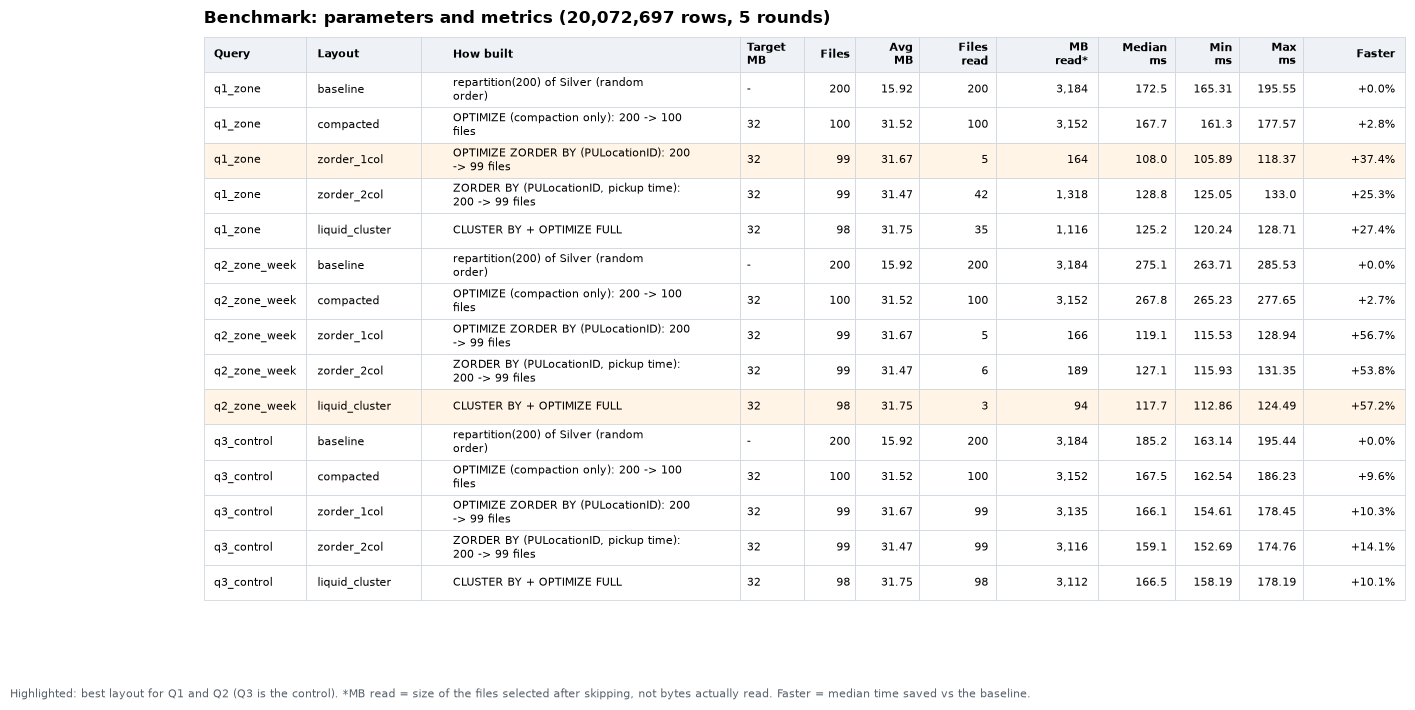

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b11_benchmark_params_metrics.png  |  source: docs/benchmark/benchmark_results.json


In [15]:
@figure("b11_benchmark_params_metrics.png")
def _():
    need("bench")
    b = E["bench"]; per = b["summary"]["per_query"]
    rows, hl = [], []
    for q, variants in per.items():
        for v, r in variants.items():
            var = b["variants"].get(v, {})
            desc = {"compacted": "OPTIMIZE (compaction only)", "zorder_1col": "OPTIMIZE ZORDER BY (PULocationID)",
                    "zorder_2col": "ZORDER BY (PULocationID, pickup time)"}.get(v, var.get("prepared_by", v))
            om = var.get("optimize_metrics", {})
            how = desc + (f": {om['numFilesRemoved']} -> {om['numFilesAdded']} files" if om else "")
            rows.append((q, v, how, b["target_file_mb"] if v != "baseline" else "-", var.get("files", "-"),
                         var.get("avg_file_mb", "-"), r["files_scanned"], f"{r['mb_read']:,.0f}", r["median_ms"], r["min_ms"], r["max_ms"],
                         f"{r['improvement_pct']:+.1f}%"))
            if q != "q3_control" and v != "baseline" and r["improvement_pct"] == max(x["improvement_pct"] for x in variants.values()):
                hl.append(len(rows) - 1)
    df = pd.DataFrame(rows, columns=["Query", "Layout", "How built", "Target\nMB", "Files", "Avg\nMB", "Files\nread", "MB\nread*",
                                     "Median\nms", "Min\nms", "Max\nms", "Faster"])
    fig = table_figure(df, f"Benchmark: parameters and metrics ({b['rows']:,} rows, {b['rounds']} rounds)", width=15.5, fontsize=7.8,
                       numeric_cols=("Files", "Avg\nMB", "Files\nread", "MB\nread*", "Median\nms", "Min\nms", "Max\nms", "Faster"),
                       highlight_rows=hl, col_widths=[0.08, 0.09, 0.25, 0.05, 0.04, 0.05, 0.06, 0.08, 0.06, 0.05, 0.05, 0.08], wrap=[14, 16, 40] + [12] * 9, row_h=0.42,
                       note="Highlighted: best layout for Q1 and Q2 (Q3 is the control). *MB read = size of the files selected after skipping, "
                            "not bytes actually read. Faster = median time saved vs the baseline.")
    save(fig, "b11_benchmark_params_metrics.png", "docs/benchmark/benchmark_results.json")

## D. Rebuttal and decision backups
### b13 — why these six months

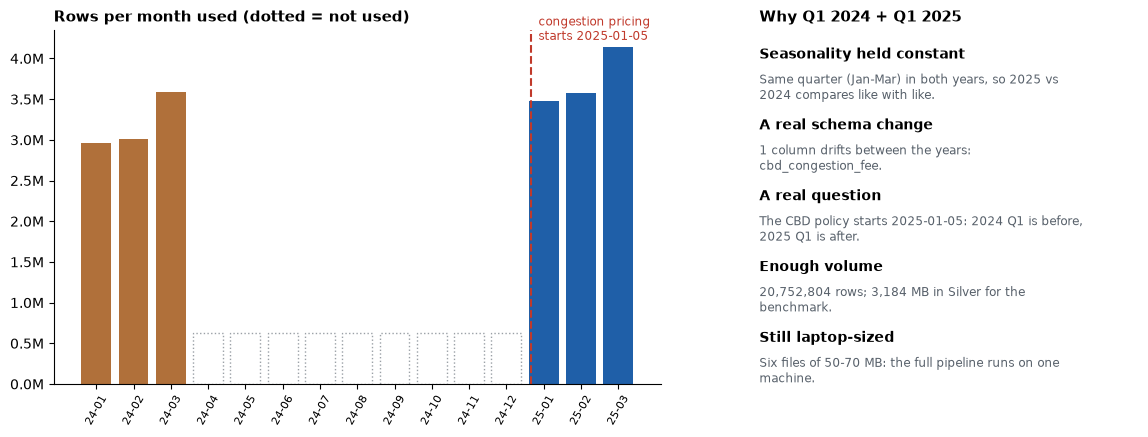

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b13_dataset_choice.png  |  source: source_data_manifest.json, src/config.py, benchmark_results.json


In [16]:
@figure("b13_dataset_choice.png")
def _():
    need("manifest", "bench")
    m = E["manifest"]; files = m["trip_files"]
    policy = date.fromisoformat(str(source_constant("src/config.py", "CBD_POLICY_START")))
    drift = [d for d in m.get("schema_drift", []) if d.get("drift")]
    months = [f"{y}-{mm:02d}" for y in (2024, 2025) for mm in range(1, 13) if f"{y}-{mm:02d}" <= "2025-03"]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.6, 1]})
    vals = [files[x]["rows"] if x in files else 0 for x in months]
    a1.bar(range(len(months)), vals, color=[C["bronze"] if x.startswith("2024") else C["delta"] for x in months])
    for i, x in enumerate(months):
        if x not in files:
            a1.bar(i, max(vals) * 0.15, color="none", edgecolor=C["grey"], ls=":")
    a1.set_xticks(range(len(months)), [x[2:] for x in months], rotation=60, fontsize=8)
    a1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
    px = months.index(f"{policy.year}-{policy.month:02d}") - 0.5 + policy.day / 31
    a1.axvline(px, color=C["accent"], ls="--"); a1.text(px + 0.2, max(vals) * 1.02, f"congestion pricing\nstarts {policy}", color=C["accent"], fontsize=8.5)
    a1.set_title("Rows per month used (dotted = not used)", fontsize=11)
    silver_mb = E["bench"]["variants"]["baseline"]["size_mb"]
    reasons = [
        ("Seasonality held constant", "Same quarter (Jan-Mar) in both years, so 2025 vs 2024 compares like with like."),
        ("A real schema change", f"{len(drift)} column drifts between the years: {', '.join(d['column'] for d in drift)}."),
        ("A real question", f"The CBD policy starts {policy}: 2024 Q1 is before, 2025 Q1 is after."),
        ("Enough volume", f"{sum(f['rows'] for f in files.values()):,} rows; {silver_mb:,.0f} MB in Silver for the benchmark."),
        ("Still laptop-sized", "Six files of 50-70 MB: the full pipeline runs on one machine."),
    ]
    a2.axis("off")
    for i, (t, d) in enumerate(reasons):
        a2.text(0, 0.95 - i * 0.2, t, weight="bold", fontsize=10, transform=a2.transAxes, va="top")
        a2.text(0, 0.88 - i * 0.2, textwrap.fill(d, 52), fontsize=8.8, transform=a2.transAxes, va="top", color=C["muted"])
    a2.set_title("Why Q1 2024 + Q1 2025", fontsize=11)
    save(fig, "b13_dataset_choice.png", "source_data_manifest.json, src/config.py, benchmark_results.json")

### b14 — file size vs best-case read (the '~1 GB' question)
With perfect clustering, a filter matching a share *s* of the rows must read at least ⌈s·N⌉ (up to ⌈s·N⌉+1) of the N = ⌈table size / target size⌉ files. Larger files lower N, so the floor rises: at ~1 GB on this table one file is already a third of it.

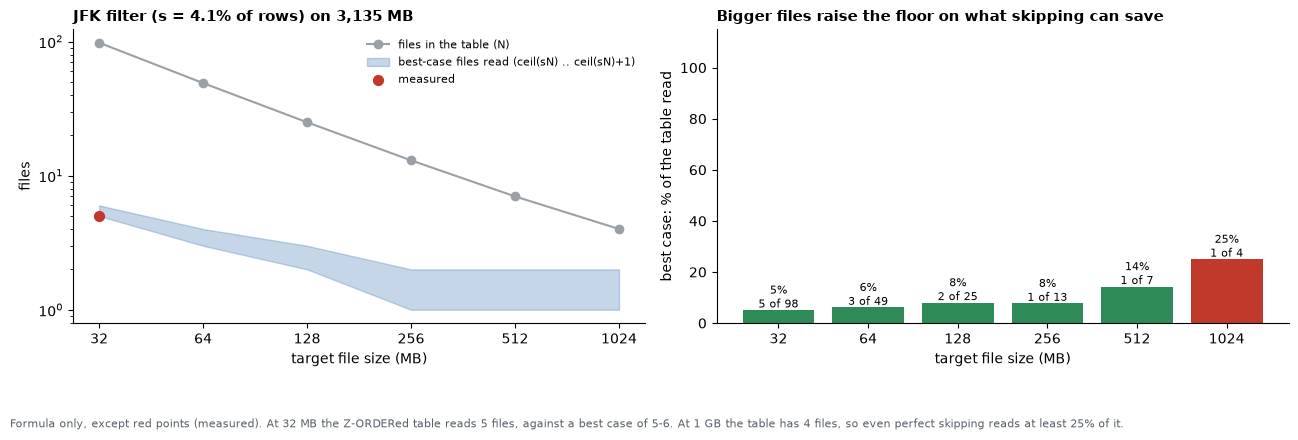

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b14_file_size_floor.png  |  source: benchmark_results.json (+ formula)


In [17]:
def filesize_sweep(sizes_mb):
    from delta.tables import DeltaTable
    from optimization_benchmark import QUERIES, collect_scan_metrics
    out = {}
    base = Path(P.benchmark_dir) / "baseline"
    for mb in sizes_mb:
        path = Path(P.scratch_dir) / f"zorder_{mb}mb"
        shutil.rmtree(path, ignore_errors=True); shutil.copytree(base, path)
        spark.conf.set("spark.databricks.delta.optimize.maxFileSize", str(mb * 2**20))
        DeltaTable.forPath(spark, str(path)).optimize().executeZOrderBy("PULocationID")
        df = QUERIES["q1_zone"][1](load(path)); df.collect()
        out[mb] = collect_scan_metrics(df)["files_scanned"]
        shutil.rmtree(path, ignore_errors=True)
    spark.conf.unset("spark.databricks.delta.optimize.maxFileSize")
    return out

@figure("b14_file_size_floor.png")
def _():
    need("bench")
    b = E["bench"]; table_mb = b["variants"]["zorder_1col"]["size_mb"]
    q1 = b["summary"]["per_query"]["q1_zone"]
    trips = next(r["result"][0]["trips"] for r in b["runs"] if r["query"] == "q1_zone")
    s = trips / b["rows"]
    sizes = [32, 64, 128, 256, 512, 1024]
    N = [math.ceil(table_mb / t) for t in sizes]
    lo = [min(n, math.ceil(s * n)) for n in N]; hi = [min(n, math.ceil(s * n) + 1) for n in N]
    measured = {b["target_file_mb"]: q1["zorder_1col"]["files_scanned"]}
    if RUN_FILESIZE_SWEEP:
        need_spark(Path(P.benchmark_dir) / "baseline")
        measured.update(filesize_sweep([64, 256, 1024]))
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
    a1.plot(sizes, N, "o-", color=C["grey"], label="files in the table (N)")
    a1.fill_between(sizes, lo, hi, color=C["delta"], alpha=0.25, label="best-case files read (ceil(sN) .. ceil(sN)+1)")
    a1.scatter(list(measured), list(measured.values()), color=C["accent"], zorder=3, s=50, label="measured")
    a1.set_xscale("log", base=2); a1.set_yscale("log"); a1.set_xticks(sizes, [f"{t}" for t in sizes])
    a1.set_xlabel("target file size (MB)"); a1.set_ylabel("files"); a1.legend(frameon=False, fontsize=8)
    a1.set_title(f"JFK filter (s = {100*s:.1f}% of rows) on {table_mb:,.0f} MB", fontsize=11)
    frac_lo = [100 * l / n for l, n in zip(lo, N)]
    a2.bar([str(t) for t in sizes], frac_lo, color=[C["ok"] if f < 20 else C["accent"] for f in frac_lo])
    for i, (f, n, l) in enumerate(zip(frac_lo, N, lo)):
        a2.text(i, f + 1, f"{f:.0f}%\n{l} of {n}", ha="center", fontsize=8)
    a2.set_xlabel("target file size (MB)"); a2.set_ylabel("best case: % of the table read"); a2.set_ylim(0, 115)
    a2.set_title("Bigger files raise the floor on what skipping can save", fontsize=11)
    footnote(fig, f"Formula only, except red points (measured). At {b['target_file_mb']} MB the Z-ORDERed table reads {q1['zorder_1col']['files_scanned']} files, "
                  f"against a best case of {lo[0]}-{hi[0]}. At 1 GB the table has {N[-1]} files, so even perfect skipping reads at least {frac_lo[-1]:.0f}% of it.", 0.12)
    save(fig, "b14_file_size_floor.png", "benchmark_results.json (+ formula" + (", measured sweep)" if RUN_FILESIZE_SWEEP else ")"))

### b15 — the control query (Q3): no skipping, so its time change is noise

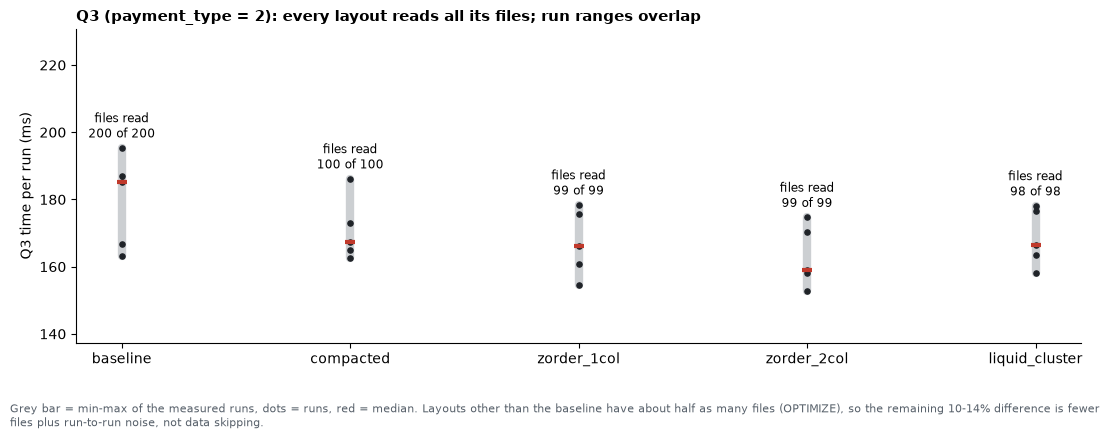

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b15_control_query.png  |  source: docs/benchmark/benchmark_results.json (individual runs)


In [18]:
@figure("b15_control_query.png")
def _():
    need("bench")
    b = E["bench"]; per = b["summary"]["per_query"]["q3_control"]
    runs = [r for r in b["runs"] if r["query"] == "q3_control" and not r.get("warmup")]
    variants = list(per)
    fig, ax = plt.subplots(figsize=(11, 4.4))
    for i, v in enumerate(variants):
        ms = [r["ms"] for r in runs if r["variant"] == v]
        ax.plot([i, i], [min(ms), max(ms)], color=C["grey"], lw=6, alpha=0.5, solid_capstyle="round")
        ax.scatter([i] * len(ms), ms, color=C["text"], s=14, zorder=3)
        ax.scatter([i], [statistics.median(ms)], color=C["accent"], s=60, marker="_", lw=3, zorder=4)
        ax.text(i, max(ms) + 3, f"files read\n{per[v]['files_scanned']} of {b['variants'].get(v, {}).get('files', '?')}", ha="center", fontsize=8.5)
    ax.set_xticks(range(len(variants)), variants); ax.set_ylabel("Q3 time per run (ms)")
    base = [r["ms"] for r in runs if r["variant"] == "baseline"]
    others = [r["ms"] for r in runs if r["variant"] != "baseline"]
    overlap = min(base) <= max(others)
    ax.set_title(f"Q3 (payment_type = 2): every layout reads all its files; run ranges {'overlap' if overlap else 'do not overlap'}", fontsize=11)
    ax.set_ylim(min(r['ms'] for r in runs) * 0.9, max(r['ms'] for r in runs) * 1.18)
    footnote(fig, "Grey bar = min-max of the measured runs, dots = runs, red = median. Layouts other than the baseline have about half as many "
                  "files (OPTIMIZE), so the remaining 10-14% difference is fewer files plus run-to-run noise, not data skipping.", 0.12)
    save(fig, "b15_control_query.png", "docs/benchmark/benchmark_results.json (individual runs)")

### b16 — TOTAL_MISMATCH before and after the rule fix (the gap histogram already exists as `total_mismatch_gaps.png`)

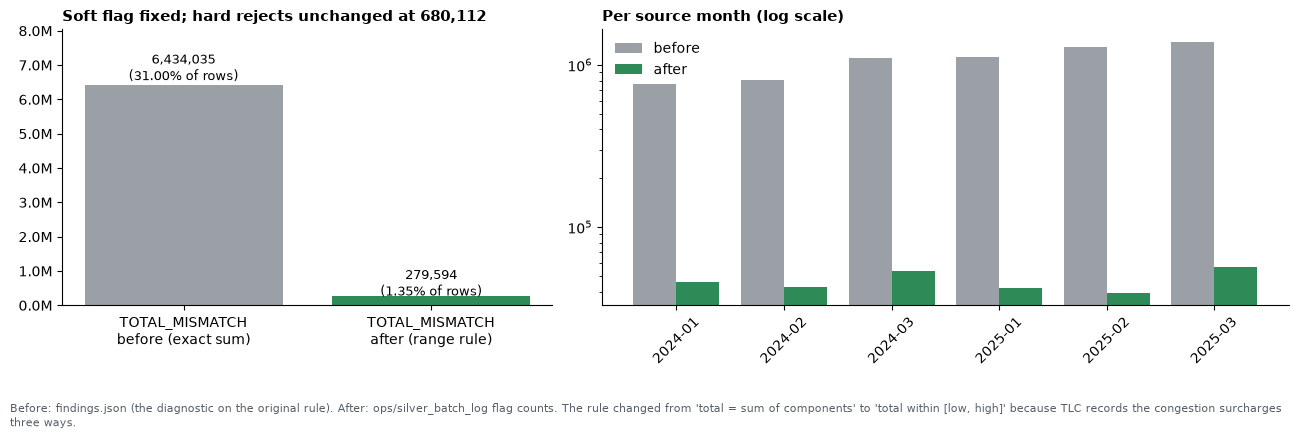

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b16_total_mismatch_before_after.png  |  source: findings.json + silver_batch_log


In [19]:
def batch_log_counts():
    """Per-batch reject reasons and flags from ops/silver_batch_log (needs Spark)."""
    if spark is None or not table_ok(P.silver_batch_log):
        return None
    rows = load(P.silver_batch_log).collect()
    return {r["batch_id"]: dict(rejects=json.loads(r["reject_reason_counts"] or "{}"), flags=json.loads(r["flag_counts"] or "{}"),
                                month=r["source_month"]) for r in rows}

@figure("b16_total_mismatch_before_after.png")
def _():
    need("findings")
    before_m = {r["_source_month"]: r["mismatched_rows"] for r in E["findings"]["total_mismatch"]["per_month"]}
    dq = dq_rules_numbers(); log = batch_log_counts()
    after_m = None
    if log:
        after_m = {v["month"]: v["flags"].get("TOTAL_MISMATCH", 0) for k, v in log.items() if k.startswith("yellow_")}
    if after_m is None and dq is None:
        raise SkipFigure("no 'after' numbers: run with Spark (batch log) or keep docs/DQ_RULES.md")
    total_before = sum(before_m.values()); total_after = sum(after_m.values()) if after_m else dq["after"]
    rows_total = sum(b["bronze"] for b in batches() if not b["synthetic"])
    hard = sum(b["rejected"] for b in batches())
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.4]})
    vals = [total_before, total_after]
    a1.bar(["TOTAL_MISMATCH\nbefore (exact sum)", "TOTAL_MISMATCH\nafter (range rule)"], vals, color=[C["grey"], C["ok"]])
    for i, v in enumerate(vals):
        a1.text(i, v * 1.02, f"{fmt(v)}\n({100*v/rows_total:.2f}% of rows)", ha="center", fontsize=9)
    a1.set_ylim(0, total_before * 1.25); a1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
    a1.set_title(f"Soft flag fixed; hard rejects unchanged at {fmt(dq['hard'] if dq else hard)}", fontsize=11)
    months = sorted(before_m); x = np.arange(len(months))
    a2.bar(x - 0.2, [before_m[m] for m in months], 0.4, color=C["grey"], label="before")
    if after_m:
        a2.bar(x + 0.2, [after_m.get(m, 0) for m in months], 0.4, color=C["ok"], label="after")
    a2.set_xticks(x, months, rotation=45); a2.set_yscale("log"); a2.legend(frameon=False)
    a2.set_title("Per source month (log scale)" + ("" if after_m else ": 'after' per month needs the batch log"), fontsize=11)
    footnote(fig, "Before: findings.json (the diagnostic on the original rule). After: "
                  + ("ops/silver_batch_log flag counts." if after_m else "docs/DQ_RULES.md (measured on the full rebuild).")
                  + " The rule changed from 'total = sum of components' to 'total within [low, high]' because TLC records the congestion surcharges three ways.", 0.12)
    save(fig, "b16_total_mismatch_before_after.png", "findings.json + " + ("silver_batch_log" if after_m else "DQ_RULES.md"))

### b17 — collisions and CDC, honestly counted

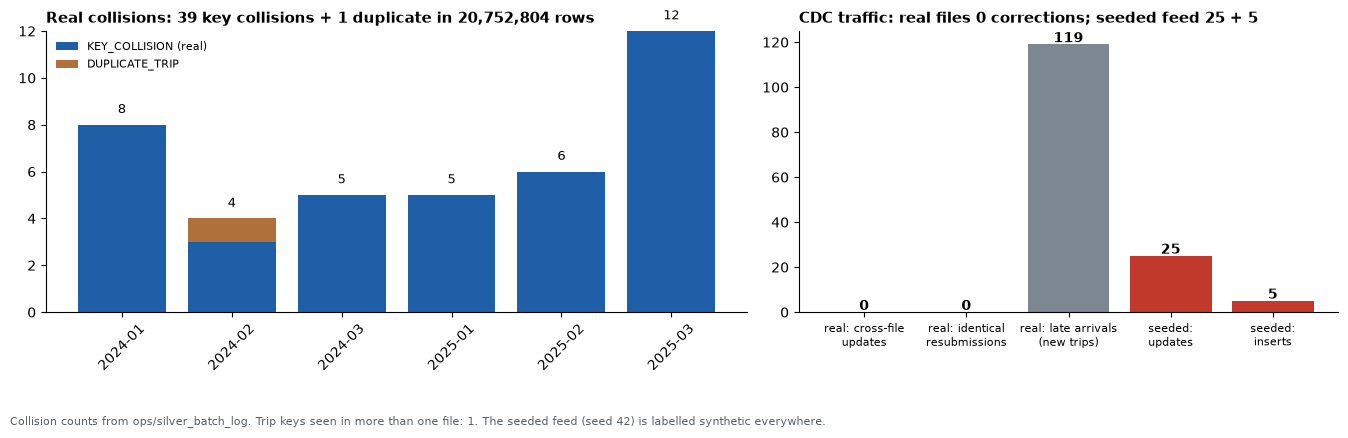

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b17_collisions_cdc_honesty.png  |  source: ops/silver_batch_log, cdc_merge.json


In [20]:
@figure("b17_collisions_cdc_honesty.png")
def _():
    need("profile", "cdc")
    B = [b for b in batches() if not b["synthetic"]]
    log = batch_log_counts()
    prev = E["profile"]["rule_preview"]["reject_reason"]
    months, coll, dup, removed, src = [], [], [], [], ""
    for b in B:
        m = b["month"]; months.append(m)
        if log and b["batch"] in log:
            r = log[b["batch"]]["rejects"]; coll.append(r.get("KEY_COLLISION", 0)); dup.append(r.get("DUPLICATE_TRIP", 0)); removed.append(0)
            src = "ops/silver_batch_log"
        else:
            r = dict(prev.get(m, {})); extra = max(0, sum(r.values()) - b["rejected"])
            k = r.get("KEY_COLLISION", 0); fix = min(extra, k)
            coll.append(k - fix); dup.append(r.get("DUPLICATE_TRIP", 0)); removed.append(fix)
            src = "profile dry run, corrected to the Silver totals"
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})
    x = np.arange(len(months))
    a1.bar(x, coll, color=C["delta"], label="KEY_COLLISION (real)")
    a1.bar(x, dup, bottom=coll, color=C["bronze"], label="DUPLICATE_TRIP")
    if any(removed):
        a1.bar(x, removed, bottom=np.array(coll) + np.array(dup), color="white", edgecolor=C["accent"], hatch="//",
               label="counted by the profile, but synthetic CDC rows (removed)")
    for i in x:
        a1.text(i, coll[i] + dup[i] + removed[i] + 0.5, f"{coll[i] + dup[i]}", ha="center", fontsize=9)
    a1.set_xticks(x, months, rotation=45); a1.legend(frameon=False, fontsize=8)
    a1.set_title(f"Real collisions: {sum(coll)} key collisions + {sum(dup)} duplicate in {sum(b['bronze'] for b in B):,} rows", fontsize=10.5)
    real = E["cdc"]["real_cdc_from_monthly_files"]
    labels = ["real: cross-file\nupdates", "real: identical\nresubmissions", "real: late arrivals\n(new trips)", "seeded:\nupdates", "seeded:\ninserts"]
    vals = [real["cross_file_updates"], real["cross_file_noop_resubmissions"], real["late_arrivals_inserted"],
            E["cdc"]["merge_metrics"]["updated"], E["cdc"]["merge_metrics"]["inserted"]]
    a2.bar(labels, vals, color=[C["grey"], C["grey"], C["silver"], C["accent"], C["accent"]])
    for i, v in enumerate(vals):
        a2.text(i, v + 1, str(v), ha="center", fontsize=10, weight="bold")
    a2.tick_params(axis="x", labelsize=8)
    a2.set_title(f"CDC traffic: real files {real['cross_file_updates']} corrections; seeded feed {vals[3]} + {vals[4]}", fontsize=10.5)
    footnote(fig, f"Collision counts from {src}. Trip keys seen in more than one file: "
                  f"{E['profile']['keys']['keys_seen_in_more_than_one_file']}. The seeded feed (seed {E['cdc']['seed']}) is labelled synthetic everywhere.", 0.1)
    save(fig, "b17_collisions_cdc_honesty.png", src + ", cdc_merge.json")

### b18 — limitations (five items, each with what it means)

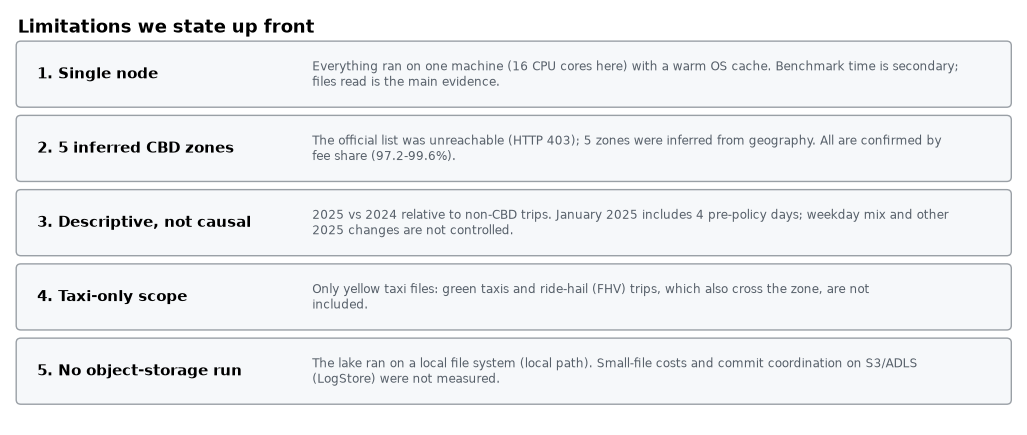

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b18_limitations.png  |  source: cbd_zone_validation.json, src/config.py, source_data_manifest.json, pipeline_run.json


In [21]:
@figure("b18_limitations.png")
def _():
    need("cbd_zones", "run", "manifest")
    z = pd.DataFrame(E["cbd_zones"])
    inferred = z[(z.is_cbd) & (z.cbd_source == "inferred_geography")]
    policy = date.fromisoformat(str(source_constant("src/config.py", "CBD_POLICY_START")))
    pre_days = (policy - date(policy.year, 1, 1)).days
    kinds = sorted({f.split("_tripdata")[0] for f in (v["file"] for v in E["manifest"]["trip_files"].values())})
    lake = E["run"].get("lake", "")
    items = [
        ("Single node", f"Everything ran on one machine ({CORES} here) with a warm OS cache. Benchmark time is secondary; files read is the main evidence."),
        (f"{len(inferred)} inferred CBD zones", f"The official list was unreachable (HTTP 403); {len(inferred)} zones were inferred from geography. "
                                                f"All are confirmed by fee share ({100*inferred.fee_share.min():.1f}-{100*inferred.fee_share.max():.1f}%)."),
        ("Descriptive, not causal", f"2025 vs 2024 relative to non-CBD trips. January 2025 includes {pre_days} pre-policy days; weekday mix and other 2025 changes are not controlled."),
        ("Taxi-only scope", f"Only {', '.join(kinds)} taxi files: green taxis and ride-hail (FHV) trips, which also cross the zone, are not included."),
        ("No object-storage run", f"The lake ran on a local file system ({'local path' if lake.startswith('/') else lake}). Small-file costs and commit "
                                   "coordination on S3/ADLS (LogStore) were not measured."),
    ]
    fig, ax = canvas(13, 5.4, (0, 13), (0, 5.6))
    ax.text(0.1, 5.35, "Limitations we state up front", fontsize=13, weight="bold", va="center")
    for i, (t, d) in enumerate(items):
        y = 4.3 - i * 1.0
        ax.add_patch(FancyBboxPatch((0.1, y), 12.8, 0.85, boxstyle="round,pad=0.02,rounding_size=0.06", fc=C["pale"], ec=C["grey"]))
        ax.text(0.35, y + 0.42, f"{i + 1}. {t}", weight="bold", fontsize=10.5, va="center")
        ax.text(3.9, y + 0.42, textwrap.fill(d, 105), fontsize=8.8, va="center", color=C["muted"])
    save(fig, "b18_limitations.png", "cbd_zone_validation.json, src/config.py, source_data_manifest.json, pipeline_run.json")

### b19 — rubric vs our design (+ a measured plain-Parquet row when Spark and the benchmark baseline are available)
The plain-Parquet run reads the **same 200 files** as the Delta baseline, but as plain Parquet (no Delta log, so no file statistics). Nothing is written.

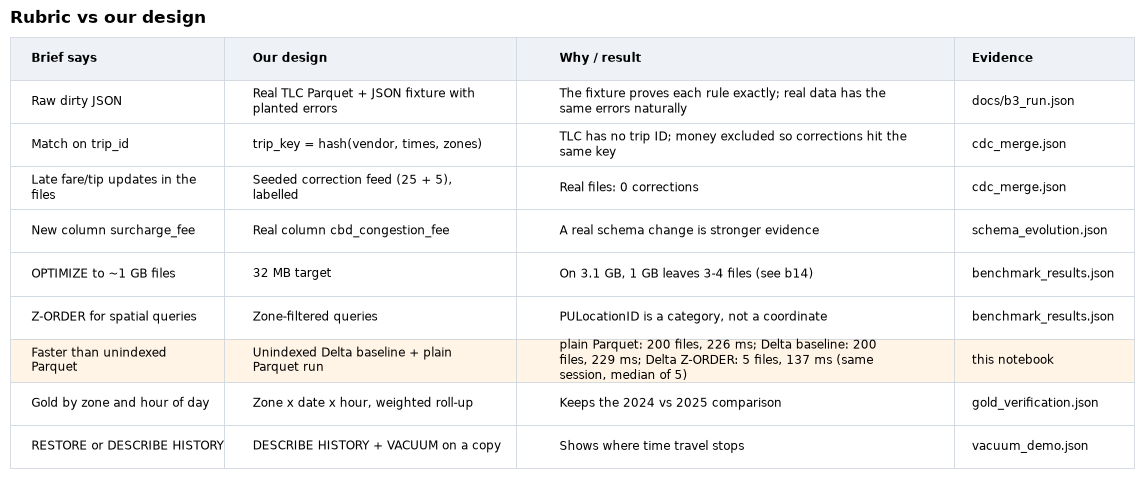

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b19_rubric_vs_design.png  |  source: evidence files + live plain-Parquet run


In [22]:
def plain_parquet_q1():
    from optimization_benchmark import QUERIES, collect_scan_metrics
    base = Path(P.benchmark_dir) / "baseline"
    files = [p for p in base.rglob("*.parquet") if "_delta_log" not in p.parts]
    if len(files) != E["bench"]["variants"]["baseline"]["files"]:
        raise SkipFigure(f"baseline folder holds {len(files)} Parquet files, not {E['bench']['variants']['baseline']['files']}: not comparable")
    query = QUERIES["q1_zone"][1]
    out = {}
    for name, reader in (("plain Parquet", lambda: spark.read.parquet(str(base))),
                         ("Delta baseline", lambda: load(base)),
                         ("Delta Z-ORDER", lambda: load(Path(P.benchmark_dir) / "zorder_1col"))):
        ms = timed(lambda: query(reader()).collect(), repeats=5)
        df = query(reader()); df.collect()
        out[name] = dict(ms=statistics.median(ms), files=collect_scan_metrics(df)["files_scanned"])
    return out

@figure("b19_rubric_vs_design.png")
def _():
    need("bench")
    q1 = E["bench"]["summary"]["per_query"]["q1_zone"]; tgt = E["bench"]["target_file_mb"]
    pq_row = None
    if spark is not None and (Path(P.benchmark_dir) / "baseline").exists():
        try:
            pq_row = plain_parquet_q1()
        except SkipFigure as e:
            print("plain-Parquet row skipped:", e)
    measured = ("; ".join(f"{k}: {v['files']} files, {v['ms']:.0f} ms" for k, v in pq_row.items()) + " (same session, median of 5)"
                if pq_row else "not run (needs Spark + benchmark baseline)")
    rows = [
        ("Raw dirty JSON", "Real TLC Parquet + JSON fixture with planted errors", "The fixture proves each rule exactly; real data has the same errors naturally", "docs/b3_run.json"),
        ("Match on trip_id", "trip_key = hash(vendor, times, zones)", "TLC has no trip ID; money excluded so corrections hit the same key", "cdc_merge.json"),
        ("Late fare/tip updates in the files", "Seeded correction feed (25 + 5), labelled", "Real files: 0 corrections", "cdc_merge.json"),
        ("New column surcharge_fee", "Real column cbd_congestion_fee", "A real schema change is stronger evidence", "schema_evolution.json"),
        ("OPTIMIZE to ~1 GB files", f"{tgt} MB target", "On 3.1 GB, 1 GB leaves 3-4 files (see b14)", "benchmark_results.json"),
        ("Z-ORDER for spatial queries", "Zone-filtered queries", "PULocationID is a category, not a coordinate", "benchmark_results.json"),
        ("Faster than unindexed Parquet", "Unindexed Delta baseline" + (" + plain Parquet run" if pq_row else ""), measured, "this notebook" if pq_row else "-"),
        ("Gold by zone and hour of day", "Zone x date x hour, weighted roll-up", "Keeps the 2024 vs 2025 comparison", "gold_verification.json"),
        ("RESTORE or DESCRIBE HISTORY", "DESCRIBE HISTORY + VACUUM on a copy", "Shows where time travel stops", "vacuum_demo.json"),
    ]
    df = pd.DataFrame(rows, columns=["Brief says", "Our design", "Why / result", "Evidence"])
    fig = table_figure(df, "Rubric vs our design", width=14.5, col_widths=[0.19, 0.26, 0.39, 0.16], fontsize=8.3,
                       highlight_rows=[6] if pq_row else [], row_h=0.5, wrap=[28, 38, 58, 24])
    save(fig, "b19_rubric_vs_design.png", "evidence files" + (" + live plain-Parquet run" if pq_row else ""))

## E. Data-science view
### b20 — dataset card: Silver and Gold schemas, sizes, and why each derived column exists

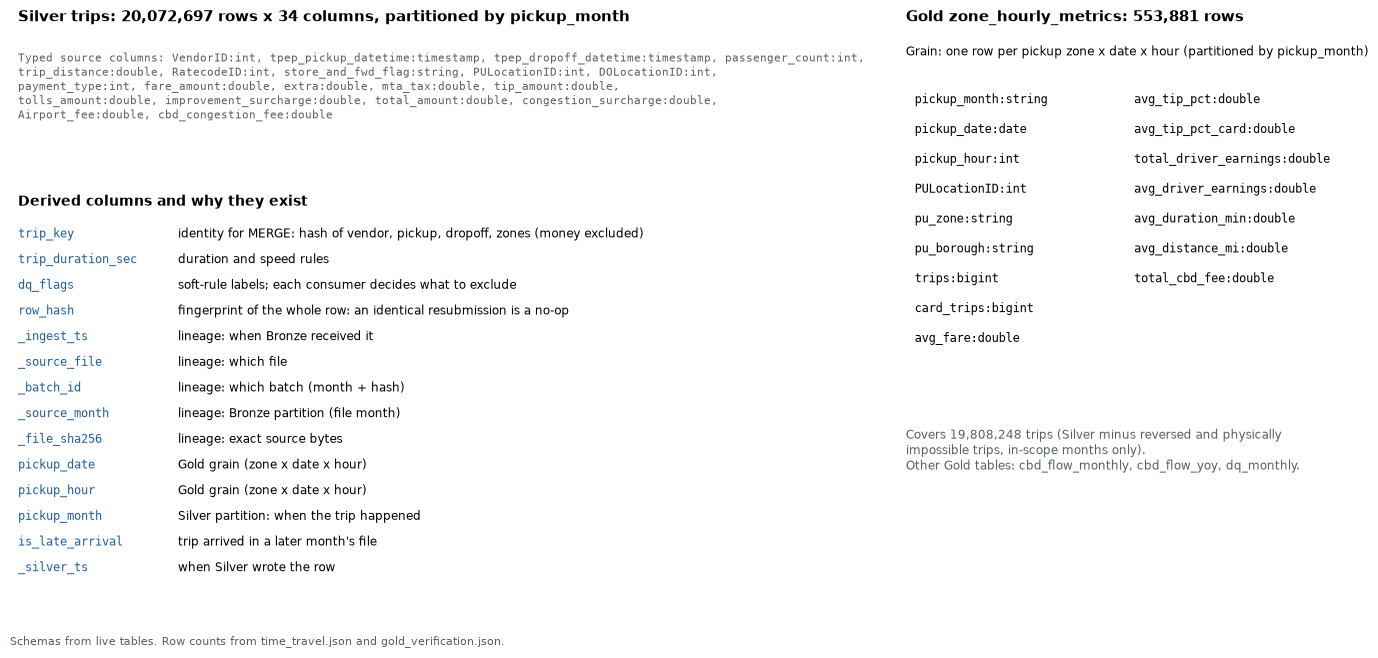

saved /home/lam/Bigdata/lakehouse-opt/report/figures/backup/b20_dataset_card.png  |  source: live tables


In [23]:
WHY = {
    "trip_key": "identity for MERGE: hash of vendor, pickup, dropoff, zones (money excluded)",
    "row_hash": "fingerprint of the whole row: an identical resubmission is a no-op",
    "trip_duration_sec": "duration and speed rules",
    "dq_flags": "soft-rule labels; each consumer decides what to exclude",
    "pickup_date": "Gold grain (zone x date x hour)", "pickup_hour": "Gold grain (zone x date x hour)",
    "pickup_month": "Silver partition: when the trip happened",
    "is_late_arrival": "trip arrived in a later month's file",
    "_silver_ts": "when Silver wrote the row",
    "_ingest_ts": "lineage: when Bronze received it", "_source_file": "lineage: which file",
    "_batch_id": "lineage: which batch (month + hash)", "_source_month": "lineage: Bronze partition (file month)",
    "_file_sha256": "lineage: exact source bytes",
}

def gold_columns_from_source():
    text = (REPO / "src/gold.py").read_text()
    m = re.search(r"def build_zone_hourly.*?(?=\ndef )", text, re.S)
    if not m:
        return []
    group = re.search(r"groupBy\(([^)]*)\)", m[0])
    keys = re.findall(r'"(\w+)"', group[1]) if group else []
    return keys + re.findall(r'alias\("(\w+)"\)', m[0])

@figure("b20_dataset_card.png")
def _():
    need("schema", "tt", "gold")
    if spark is not None and table_ok(P.silver_trips):
        silver_cols = [f"{n}:{t}" for n, t in load(P.silver_trips).dtypes]
        gold_cols = [f"{n}:{t}" for n, t in load(P.gold_zone_hourly).dtypes] if table_ok(P.gold_zone_hourly) else gold_columns_from_source()
        src = "live tables"
    else:
        ev = E["schema"]["silver"]
        silver_cols = next(c["columns"] for c in ev["schema_changes"] if c["event"] == "CREATE") + ev["evolution_event"]["added"]
        gold_cols = gold_columns_from_source()
        src = "schema_evolution.json + src/gold.py"
    names = [c.split(":")[0] for c in silver_cols]
    derived = [n for n in names if n in WHY]
    source = [c for c, n in zip(silver_cols, names) if n not in WHY]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6.6), gridspec_kw={"width_ratios": [1.35, 1]})
    for a in (a1, a2):
        a.axis("off")
    silver_rows = E["tt"]["silver_rows_per_version"][-1]
    a1.text(0, 1.0, f"Silver trips: {silver_rows['rows']:,} rows x {len(silver_cols)} columns, partitioned by pickup_month",
            weight="bold", fontsize=11, transform=a1.transAxes, va="top")
    src_text = "Typed source columns: " + textwrap.fill(", ".join(source), 105)
    a1.text(0, 0.93, src_text, fontsize=8, family="monospace", transform=a1.transAxes, va="top", color=C["muted"])
    y = 0.93 - 0.04 * (src_text.count("\n") + 1) - 0.04
    a1.text(0, y, "Derived columns and why they exist", weight="bold", fontsize=10, transform=a1.transAxes, va="top"); y -= 0.055
    for n in derived:
        a1.text(0, y, n, family="monospace", fontsize=8.3, transform=a1.transAxes, va="top", color=C["delta"])
        a1.text(0.27, y, WHY[n], fontsize=8.3, transform=a1.transAxes, va="top"); y -= 0.043
    a2.text(0, 1.0, f"Gold zone_hourly_metrics: {E['gold']['zone_hourly_rows']:,} rows", weight="bold", fontsize=11, transform=a2.transAxes, va="top")
    a2.text(0, 0.94, "Grain: one row per pickup zone x date x hour (partitioned by pickup_month)", fontsize=8.8, transform=a2.transAxes, va="top")
    for i, c in enumerate(gold_cols):
        a2.text(0.02 + 0.5 * (i // 9), 0.86 - 0.05 * (i % 9), c, family="monospace", fontsize=8.3, transform=a2.transAxes, va="top")
    a2.text(0, 0.3, f"Covers {E['gold']['gold_trips']:,} trips (Silver minus reversed and physically\nimpossible trips, in-scope months only).\n"
                    f"Other Gold tables: cbd_flow_monthly, cbd_flow_yoy, dq_monthly.", fontsize=8.8, transform=a2.transAxes, va="top", color=C["muted"])
    footnote(fig, f"Schemas from {src}. Row counts from time_travel.json and gold_verification.json.", 0.05)
    save(fig, "b20_dataset_card.png", src)

## Summary

In [24]:
EXPECTED = ["b01_master_flow.png", "b02_row_conservation_waterfall.png", "b03_question_evidence_map.png", "b04_spark_feature_table.png",
            "b05_physical_plans.png", "b06_spark_stage_view_dedup.png", "b07_broadcast_vs_sortmerge.png", "b08_shuffle_partitions_sweep.png",
            "b09_merge_cost_deletion_vectors.png", "b10_run_configuration.png", "b11_benchmark_params_metrics.png", "b13_dataset_choice.png",
            "b14_file_size_floor.png", "b15_control_query.png", "b16_total_mismatch_before_after.png", "b17_collisions_cdc_honesty.png",
            "b18_limitations.png", "b19_rubric_vs_design.png", "b20_dataset_card.png"]
summary = pd.DataFrame([(n, *RESULTS.get(n, ("not run", ""))) for n in EXPECTED], columns=["figure", "status", "source / reason"])
print(f"{(summary.status == 'created').sum()} created, {(summary.status == 'skipped').sum()} skipped, "
      f"{(summary.status == 'failed').sum()} failed  ->  {FIG_DIR}")
summary

19 created, 0 skipped, 0 failed  ->  /home/lam/Bigdata/lakehouse-opt/report/figures/backup


,figure,status,source / reason
0,b01_master_flow.png,created,all evidence files (see boxes)
1,b02_row_conservation_waterfall.png,created,"bronze_history.json, silver_history.json"
2,b03_question_evidence_map.png,created,evidence files listed in the table
3,b04_spark_feature_table.png,created,source code search
4,b05_physical_plans.png,created,executed plans on 2025-03 and benchmark/zorder...
5,b06_spark_stage_view_dedup.png,created,Spark UI REST API (stages of one dedup job)
6,b07_broadcast_vs_sortmerge.png,created,live runs on Silver + dim_zone
7,b08_shuffle_partitions_sweep.png,created,live runs on Silver
8,b09_merge_cost_deletion_vectors.png,created,silver_history.json
9,b10_run_configuration.png,created,"pipeline_run.json, benchmark_results.json, cdc..."


**Not regenerated here:** #12 (`version_timeline.png`, `silver_history.png`) and the gap histogram of #16 (`total_mismatch_gaps.png`) come from `report_figures.ipynb`.